# LDA individuality — figures for the paper

Companion to `lda_shrinkage.ipynb`: the same data, filters and shrinkage LDA, scored in the ways
a paper figure needs.

* **Figure 1** — mouse identification when one *session*, one *mouse* or one *lab* is held out,
  against shuffled-label and raw-feature controls, overall and per lab.
* **Figure 2** — dimensionality: held-out variance explained per discriminant, identification
  in the first *k* discriminants (vs PCA), the distance structure (own mouse / labmates / other
  labs), and where the errors go.
* **Supplementary** — sensitivity to shrinkage and sessions per mouse, identity carried by each
  trial epoch and syllable channel, per-mouse accuracy.

The LD1/LD2 scatter and the structural-coefficient profiles are in `lda_shrinkage.ipynb` and are
not repeated here. Why the LDA uses shrinkage and no PCA step is explained in that notebook's
header.

The cells down to "Lab variance" are copied from `lda_shrinkage.ipynb`. Keep the two in sync.
Runtime: about 15 min on 8 cores at the default repeats, mostly the nested LOSO loop (folds run in parallel, see `N_JOBS`).

In [1]:
# ---- DATA FILTERING ---------------------------------------------------------------
QC_STRICTNESS = 'filtered_out'
# Which sessions the curated QC sheet removes (session_filters.exclusions_by_timepoint):
#   'filtered_out'            -> 'Used in paper' == 'filtered out'      (12 sessions)
#   'filtered_out_and_revise' -> those PLUS 'need to revise'            (21 sessions)

MAX_SESSION_MISSING = 0.1
# Drop sessions with more than this fraction of NaN bins. None keeps every session.
# At 0.1 this costs 8 sessions and 2 mice (CSH_ZAD_026, NYU-30), both right-paw tracking
# dropouts. Below ~1% it stops screening artifacts and starts screening ordinary sessions.

MIN_SESSIONS_PER_MOUSE = 3
# A mouse needs at least this many surviving sessions to stay a class. Applied AFTER the
# other screens, so raising MAX_SESSION_MISSING can remove a mouse without naming it.

DROP_INCOMPLETE_TRIALS = False
# Trial-level screen: drop any trial with a missing bin in any of its four epochs, rather
# than letting the per-session mean skip it. The honest test of whether missing data
# biases the features, since no mouse and no session leaves. Reproduces LD1 at |r| = 0.994.

SYLLABLE_CHANNELS = ('paw', 'whisk', 'lick')
# Any subset. A syllable is (paw state, whisking on/off, licking on/off) and binarize()
# lays each timestep out as 7 paw one-hot columns (state 1 is the dropped reference) +
# whisk + lick, so a channel is a clean column subset.
#
#   channels             feat    lab var   mouse ID   lab from held-out mouse
#   paw + whisk + lick    360      0.166     0.848          0.398
#   paw + whisk           320      0.114     0.794          0.297
#   paw only              280      0.042     0.736          0.234
#
# Paw-only is the only subset with no detectable lab effect (p = 0.111) and still
# identifies the mouse at 0.736 of 56. Changing this changes the feature space, so LD1
# from a paw-only run is not the LD1 quoted elsewhere -- refit every correlate.

# ---- LAB VARIANCE -----------------------------------------------------------------
LAB_CORRECTION = 'none'      # 'none' | 'center' | 'zscore'
# Applied to the session x feature matrix before the LDA, by functions.remove_lab_variance.
# READ THIS BEFORE TURNING IT ON. Lab is NESTED INSIDE MOUSE, so this is not a nuisance
# regressor that leaves the signal intact: after centring, the corrected mouse means within
# a lab sum to zero and mouse identity loses one dimension per lab (10 of 55 here). Expect
# the score to fall, and to fall further for mice in small labs. The honest use is a
# COMPARISON -- run 'none' and 'center' and report both. What survives is individuality not
# explained by lab; what does not is either lab nuisance or lab-linked individuality, and
# this design cannot separate those.

FEATURE_NORM = None          # None | 'global' | 'per_lab'
# Rank-based inverse-normal transform of each feature (Forkosh et al. 2019 quantile
# normalisation). Monotone but NONLINEAR, so unlike any rescaling it is something the LDA
# can actually see. The features are session means of binary indicators, i.e. proportions,
# and strongly skewed (median per-feature skew 1.31, max 10.02).
#   'global'   one ranking per feature over all sessions
#   'per_lab'  rank within lab -- the only setting here that removes lab variance
#              (0.177 -> 0.000), and it pays the same nesting cost as LAB_CORRECTION.

# ---- LDA PROTOCOL -----------------------------------------------------------------
N_PER_MOUSE = 3
# Cap on each mouse's contribution to a training set, so a 16-session mouse does not set
# the whitening metric for everyone. A MAXIMUM, not a minimum: sparse mice contribute what
# they have and every mouse stays a class. This also sets the df budget the header
# describes -- raising it raises n_training_sessions and so raises the within-class df.

SHRINKAGE_GRID = (0.05, 0.1, 0.2, 0.3, 0.5)
# Candidate values for the inner loop. Fixed floats, not 'auto' -- see the header.

N_REPEATS = 1
INNER_FOLDS = 3
# Cost is N_REPEATS x n_sessions x (INNER_FOLDS x len(SHRINKAGE_GRID) + 2) fits, about
# 80 ms each: roughly 6 minutes per repeat on 260 sessions. Drop INNER_FOLDS to 2 or
# shorten the grid if you are iterating.

EMBEDDING_WEIGHTING = 'mouse'      # 'mouse' | 'session'
# How the all-sessions EMBEDDING (and the saved file) weighs mice with unequal session counts
# (3 to 16). Does NOT affect the cross-validated score, whose training sets are capped at
# N_PER_MOUSE sessions per mouse either way.
#   'session'  sklearn's eigen solver. Its between-mouse scatter is S_T - S_W with S_T pooled
#              over SESSIONS, so a 16-session mouse counts ~5x a 3-session one in deciding
#              which differences between mice matter.
#   'mouse'    between-mouse scatter from the 56 mouse means, each counted once (a mean still
#              uses all of that mouse's sessions); within-mouse scatter pooled over sessions.
#              Shrinkage chosen by its own CV with the one-SE rule (embedding cell).
# Compared 01-10-2026 at shrinkage 0.5: LD1 r = 0.97 (sessions), 0.98 (mouse means); LD1 with
# hausserlab dropped 0.92 vs 0.83 for 'session'; top-5 subspace overlap 0.94; lab eta^2 of LD1
# unchanged (0.36). But LD2 and several higher axes are RELABELLED (same-axis |r| ~0.55), so a
# result on any single axis beyond LD1 from a 'session' file does not carry over.


### Figure style

`paper_style` holds every cross-figure decision — colours, panel sizes, where figures are
written. Run this before the imports cell.

In [2]:
# ---- FIGURE STYLE -----------------------------------------------------------------
import sys
import pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
sys.path.insert(0, str(_root / '4_mice'))                   # functions.py lives there
import importlib
import paper_style
importlib.reload(paper_style)      # kernels cache modules; without this, edits stay invisible
ps = paper_style
ps.use('paper')                    # 'paper' = journal sizes; 'poster' = big type

paper_style: paper mode, spines=lb, font 8 pt, panels 3.4x2.4 in, save 400 dpi


'paper'

## Imports and paths

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# EXPECTED, NOT IGNORED. In an inner fold, the one mouse whose session the OUTER loop is
# holding out can be left with a single training session, and sklearn warns when it forms
# that class's covariance from one sample. It affects at most 1 of the 56 classes and only
# in the outer folds whose test mouse has exactly MIN_SESSIONS_PER_MOUSE sessions; the
# class contributes a zero matrix to the pooled within-class scatter, which the shrinkage
# term then fills in. Silenced because it fires on every inner fit and buries the output.
warnings.filterwarnings('ignore', message='Only one sample available',
                        category=UserWarning)

base_path = str(_root / 'data') + '/'
SYLLABLE_FILE = base_path + '8_k_10_bin_syllables_19-08-2026'
SYLLABLE_FILE = base_path + '8_k_10_bin_syllables_02-10-2026'
SYLLABLE_FILE = base_path + '8_k_10_bin_syllables_19-08-2026'
# ^ OVERRIDE, set when this notebook was built: lda_shrinkage points at 8_k_10_bin_syllables_02-10-2026,
# which is not on this machine yet. Delete this line once it is.
# SYLLABLE_FILE = base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026'
N_PAW_STATES = 8
EPOCHS = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']

import session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

import functions
importlib.reload(functions)
from functions import (lab_labels, lab_variance_explained, remove_lab_variance,
                       rank_inverse_normal)

## Build the session × feature matrix

`binarize` one-hots the integer syllable codes into one block of (paw states + whisk + lick)
columns per timestep, dropping paw state 1 at every timestep as the redundant reference.
`filter_sequences` applies the QC sheet, then the missing-data screen, then the per-mouse
session minimum, in that order.

In [4]:
def binarize(use_sequences, n_paw_states=N_PAW_STATES):
    """One-hot the integer syllable codes, one block of (n_paw_states + 2) columns per
    timestep, then drop paw state 1 at every timestep as the redundant reference (the
    states sum to 1, so it is recoverable -- the structural-coefficient cell reconstructs
    it). NaN timesteps stay NaN so the per-session mean can skip them."""
    n_trials, timesteps = use_sequences.shape
    per_step = n_paw_states + 2
    out = np.zeros((n_trials, timesteps * per_step))

    for t in range(timesteps):
        vals = use_sequences[:, t]
        valid = ~np.isnan(vals)
        labels = vals[valid].astype(int)
        start = t * per_step
        if len(labels):
            rows = np.arange(n_trials)[valid]
            out[rows, start + labels % n_paw_states] = 1                    # paw state
            out[valid, start + n_paw_states] = (labels // n_paw_states) % 2  # whisk
            out[valid, start + n_paw_states + 1] = labels // (n_paw_states * 2)  # lick
        if (~valid).any():
            out[~valid, start:start + per_step] = np.nan

    return np.delete(out, [t * per_step + 1 for t in range(timesteps)], axis=1)


def filter_sequences(seq, prob_sessions):
    """QC sheet, then the missing-data screen, then the per-mouse session minimum."""
    print(f'{seq.mouse_name.nunique()} mice, {seq.session.nunique()} sessions in total')

    seq = seq.loc[~seq['session'].isin(prob_sessions)].reset_index(drop=True)
    print(f'{seq["session"].nunique()} sessions after the QC sheet ({QC_STRICTNESS})')

    before = (seq[['mouse_name', 'session']].drop_duplicates()
              .groupby('mouse_name')['session'].count())

    if MAX_SESSION_MISSING is not None:
        nan_frac = np.isnan(np.stack(seq['binned_sequence'].to_numpy())).mean(axis=1)
        by_session = (pd.Series(nan_frac, index=seq['session'].to_numpy())
                      .groupby(level=0).mean())
        drop = by_session[by_session > MAX_SESSION_MISSING]
        seq = seq.loc[~seq['session'].isin(drop.index)].reset_index(drop=True)
        print(f'{seq["session"].nunique()} sessions after dropping {len(drop)} with > '
              f'{MAX_SESSION_MISSING:.1%} missing bins'
              + (f' (worst {drop.max():.1%})' if len(drop) else ''))

    counts = (seq[['mouse_name', 'session']].drop_duplicates()
              .groupby('mouse_name')['session'].count())
    keep = counts[counts >= MIN_SESSIONS_PER_MOUSE].index
    seq = seq.loc[seq['mouse_name'].isin(keep)].reset_index(drop=True)
    print(f'{len(keep)} mice with at least {MIN_SESSIONS_PER_MOUSE} sessions, '
          f'{seq["session"].nunique()} remaining sessions')

    after = counts.reindex(before.index).fillna(0).astype(int)
    taken = before[(before >= MIN_SESSIONS_PER_MOUSE) & (after < MIN_SESSIONS_PER_MOUSE)]
    if len(taken):
        print('  mice DROPPED BY THE MISSING-DATA SCREEN: '
              + ', '.join(f'{m} {before[m]}->{after[m]}' for m in taken.index))

    assert len(seq), 'every session was filtered out'
    return seq


def build_design_matrix(filename):
    """-> (session x feature DataFrame indexed by session, session/mouse mapping)."""
    seq = pd.read_parquet(filename)
    seq['session'] = seq['sample'].str[:36]

    prob_sessions = sorted(exclusions_by_timepoint(QC_STRICTNESS)['Proficient'])
    print(f'QC sheet: {find_csv()}  ->  {len(prob_sessions)} proficient sessions dropped')
    seq = filter_sequences(seq, prob_sessions)

    # .dropna() removes trials missing an epoch entirely -- those rows carry a None rather
    # than a short array, and np.hstack below would silently build a ragged matrix.
    trials = (seq.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'],
                        columns=['broader_label'], values='binned_sequence')
              .reset_index().dropna().sort_values(by='session'))
    print(f'{len(trials)} trials, {trials["mouse_name"].nunique()} mice, '
          f'{trials["session"].nunique()} sessions')

    use_sequences = np.vstack(trials[EPOCHS].apply(lambda r: np.hstack(r), axis=1))

    if DROP_INCOMPLETE_TRIALS:
        complete = ~np.isnan(use_sequences).any(axis=1)
        print(f'  trial screen: {int(complete.sum())}/{len(complete)} complete '
              f'({1 - complete.mean():.1%} dropped)')
        use_sequences, trials = use_sequences[complete], trials[complete]

    feats = binarize(use_sequences)

    # Channel subsetting. After binarize each timestep is
    #   [paw 0, paw 2..paw 7] (n_paw_states - 1 cols) [whisk] [lick]
    assert set(SYLLABLE_CHANNELS) <= {'paw', 'whisk', 'lick'} and SYLLABLE_CHANNELS
    if set(SYLLABLE_CHANNELS) != {'paw', 'whisk', 'lick'}:
        n_paw_cols = N_PAW_STATES - 1
        per_step = n_paw_cols + 2
        within = np.arange(feats.shape[1]) % per_step
        keep = np.zeros(feats.shape[1], dtype=bool)
        if 'paw' in SYLLABLE_CHANNELS:
            keep |= within < n_paw_cols
        if 'whisk' in SYLLABLE_CHANNELS:
            keep |= within == n_paw_cols
        if 'lick' in SYLLABLE_CHANNELS:
            keep |= within == n_paw_cols + 1
        feats = feats[:, keep]
        print(f'  channels {SYLLABLE_CHANNELS}: {int(keep.sum())} of {len(keep)} features')

    frame = pd.DataFrame(feats)
    frame['session'] = trials['session'].values
    session_feats = frame.groupby('session', sort=False)[np.arange(feats.shape[1])].mean()

    mapping = trials[['session', 'mouse_name']].drop_duplicates()
    assert len(mapping) == mapping['session'].nunique(), 'a session maps to multiple mice'
    mapping = mapping.set_index('session')['mouse_name']

    print(f'✓ {len(session_feats)} sessions x {session_feats.shape[1]} features, '
          f'{mapping.nunique()} mice')
    return session_feats, mapping.reindex(session_feats.index)


session_feats, mouse_of_session = build_design_matrix(SYLLABLE_FILE)

QC sheet: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv  ->  12 proficient sessions dropped
101 mice, 332 sessions in total


330 sessions after the QC sheet (filtered_out)


322 sessions after dropping 8 with > 10.0% missing bins (worst 54.3%)


56 mice with at least 3 sessions, 260 remaining sessions
  mice DROPPED BY THE MISSING-DATA SCREEN: CSH_ZAD_026 6->1, NYU-30 3->0


159640 trials, 56 mice, 260 sessions


✓ 260 sessions x 360 features, 56 mice


## Lab variance and feature normalisation

Both act on the session × feature matrix, so everything downstream — the LDA, the embedding,
every figure — sees the corrected features.

There is deliberately **no `StandardScaler`** anywhere in this notebook. The LDA objective is
a *ratio* of between- to within-mouse spread, so it is invariant to any invertible affine map
of the features; rescaling columns cannot move the discriminants, the eigenvalues or the
score by more than numerical noise (measured: spread 0.000 across component counts). The old
pipeline's scaler on the PCA scores was a no-op that read as a modelling choice.

In [5]:
all_features = session_feats.copy()

lab_of_session = lab_labels(all_features.index, mouse_names=mouse_of_session)
n_by_lab = mouse_of_session.groupby(lab_of_session).nunique()
print('mice per lab:', ', '.join(f'{k} {v}' for k, v in n_by_lab.sort_values().items()))
print(f'lab share of feature variance (mean eta^2): '
      f'{lab_variance_explained(all_features, lab_of_session):.3f}'
      '  -- how much a lab label alone accounts for; it does NOT say the cause is the lab '
      'rather than the mice in it')

# FEATURE_NORM first, LAB_CORRECTION second: the lab correction subtracts a mean (and in
# 'zscore' mode divides by an SD), both of which are pulled around by these skewed tails.
if FEATURE_NORM not in (None, 'none'):
    all_features = rank_inverse_normal(
        all_features, groups=lab_of_session if FEATURE_NORM == 'per_lab' else None)
    print(f'  after FEATURE_NORM={FEATURE_NORM!r}: '
          f'{lab_variance_explained(all_features, lab_of_session):.3f}')

if LAB_CORRECTION not in (None, 'none'):
    all_features = remove_lab_variance(all_features, lab_of_session,
                                       mode=LAB_CORRECTION, mouse_names=mouse_of_session)
    print(f'  after LAB_CORRECTION={LAB_CORRECTION!r}: '
          f'{lab_variance_explained(all_features, lab_of_session):.3f}')

X = np.asarray(all_features, dtype=float)
mouse_names = pd.Series(mouse_of_session.to_numpy(), name='mouse_name')
y = pd.factorize(mouse_names)[0]
N_MICE = len(np.unique(y))

_n_train = int(np.minimum(pd.Series(y).value_counts(), N_PER_MOUSE).sum())
print(f'\nbalanced training set: {_n_train} sessions, {N_MICE} mice -> '
      f'{_n_train - N_MICE} within-class df against {X.shape[1]} features. '
      f'Shrinkage is what makes that solvable.')

  1 session(s) had no rig in the sheet; lab taken from the mouse
  labs: 10 for 260 sessions
mice per lab: zadorlab 2, wittenlab 3, steinmetzlab 4, churchlandlab_ucla 5, hausserlab 6, churchlandlab 7, danlab 7, mainenlab 7, mrsicflogel 7, angelakilab 8
lab share of feature variance (mean eta^2): 0.177  -- how much a lab label alone accounts for; it does NOT say the cause is the lab rather than the mice in it

balanced training set: 168 sessions, 56 mice -> 112 within-class df against 360 features. Shrinkage is what makes that solvable.


## Three generalisation tests

| test | held out | the question |
|---|---|---|
| **leave-one-session-out** | one session | is a mouse recognisable on a day the model has not seen? |
| **leave-half-of-mice-out** | a random half of the mice | do identity axes learned on some mice separate *new* mice? |
| **leave-half-of-labs-out** | every mouse of a random half of the labs (~28 mice) | do they transfer to labs, rigs and experimenters never seen? |

**Scoring.** Leave-one-session-out is the LDA's own 56-way prediction. In the two half-split
tests the held-out mice are not classes of the model, so each of their sessions is matched
to the nearest held-out mouse **centroid** in LDA space. Each centroid is built from up to
`N_PER_MOUSE` of that mouse's *other* sessions, its "enrolment" sessions. Chance is 1/k,
with k ≈ 28.

**Why half, and why only among the held-out mice.** Every candidate must be equally unseen.
Mice that did not train the axes look alike in them: their individual quirks partly fall
outside the learned directions, so they sit nearer the centre. In a 56-way test where one
unseen mouse competes against 55 training mice, that resemblance favours the unseen mouse's
own centroid. A decoy test (supplement) puts the effect at about 3× chance. Identifying among
held-out mice only removes it. Holding out half rather than one or one lab avoids the ceiling:
with ≤ 8 held-out mice, almost any representation scores ~0.9.

The mouse and lab splits are **size-matched pairwise** (split *i* of each holds out the same
number of mice). So their difference isolates what is lost when whole labs are unseen.

**The comparison on every bar: syllable space.** The same nearest-centroid identification on
the 360 syllable features themselves, z-scored with no LDA. It shows how identifiable the
mice are before any model is fit to identity.

The 56-way leave-one-*mouse*-out and leave-one-*lab*-out versions are in the supplement, with
the decoy calibration that explains why they are not the main result.

In [6]:
# ---- THIS NOTEBOOK'S KNOBS --------------------------------------------------------
N_SPLITS = 50
# Half-splits per test. Each one refits the LDA (nested shrinkage) on the other half.

HALF_SIZE = (26, 30)
# Held-out mice per split. Lab splits add whole labs in random order until reaching 26, and
# are redrawn if they overshoot 30; each mouse split then holds out the same number.

N_REPEATS_ONE_OUT = 3
N_DECOY = 150
# Supplement: repeats of the 56-way leave-one-mouse/lab-out loops, and mouse pairs for the
# decoy calibration.

N_STABILITY = 100
STABILITY_SESSIONS = 0.8
# Supplement, axis stability: refits keeping a random 80% of each mouse's sessions (min. 2).
# Leave-one-mouse-out and leave-one-lab-out refits (56 + 10) are always run alongside.

FIXED_SHRINKAGE = None
# Supplementary sweeps use ONE fixed shrinkage and no inner loop. None
# means the modal value the nested leave-one-session-out loop picked.

N_JOBS = -1
# Folds run in parallel, one BLAS thread per worker. Each fit is a few small (360 x 360)
# matrix ops, and a multithreaded BLAS spends more time coordinating its threads than
# computing them: single-process, the kernel ran at ~700% CPU with ~70% of it system time.
# Results do not depend on N_JOBS -- every fold seeds its own generator from its index.

MAX_DIMS_PLOT = 45

## Shared machinery

`balanced_draw`, `fit_lda` and `select_shrinkage` are copied unchanged from `lda_shrinkage`, so
the leave-one-session-out score matches that notebook's up to random draws. (Folds here are
seeded per fold for parallelism, so the draws are not identical.) `nearest_by_dims` scores a
query in the first 1, 2, …, K discriminants at once from one cumulative sum, so the
dimensionality curves cost nothing extra.

In [7]:
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits


def pmap(fn, items):
    """fn over items in parallel, each worker pinned to one BLAS thread."""
    def one(item):
        # workers are fresh processes and do not inherit this kernel's warning filters;
        # see the imports cell for why this one is expected
        warnings.filterwarnings('ignore', message='Only one sample available',
                                category=UserWarning)
        with threadpool_limits(1):
            return fn(item)
    return Parallel(n_jobs=N_JOBS)(delayed(one)(it) for it in items)


def fold_rng(*key):
    """One generator per fold, keyed by its indices -- reproducible at any N_JOBS."""
    return np.random.default_rng([2026, *key])


def balanced_draw(y_sub, rng, cap=N_PER_MOUSE):
    """Indices into y_sub taking at most `cap` sessions per mouse. A MAXIMUM, not a
    minimum: every mouse stays a class and sparse ones contribute what they have."""
    idx = []
    for m in np.unique(y_sub):
        m_idx = np.where(y_sub == m)[0]
        idx.extend(rng.choice(m_idx, min(cap, len(m_idx)), replace=False))
    return np.array(idx)


def fit_lda(Xt, yt, shrinkage, n_components=None):
    k = len(np.unique(yt))
    return LinearDiscriminantAnalysis(
        solver='eigen', shrinkage=shrinkage, priors=np.ones(k) / k,
        n_components=n_components).fit(Xt, yt)


def select_shrinkage(Xt, yt, rng, grid=SHRINKAGE_GRID, n_folds=INNER_FOLDS):
    """Inner CV on the outer fold's TRAINING sessions only (see lda_shrinkage)."""
    wins = np.zeros(len(grid))
    for _ in range(n_folds):
        held = np.array([rng.choice(np.where(yt == m)[0]) for m in np.unique(yt)])
        rest = np.setdiff1d(np.arange(len(yt)), held)
        tr = rest[balanced_draw(yt[rest], rng)]
        for gi, s in enumerate(grid):
            wins[gi] += np.mean(fit_lda(Xt[tr], yt[tr], s).predict(Xt[held]) == yt[held])
    return grid[int(np.argmax(wins))]


def ld_basis(lda, n_classes):
    """The C-1 discriminant directions. solver='eigen' returns them S_W-orthonormal, so
    Euclidean distance in this basis is the (shrunk) within-mouse Mahalanobis distance."""
    return lda.scalings_[:, :n_classes - 1]


def class_centroids(Z, labels):
    classes = np.unique(labels)
    return classes, np.stack([Z[labels == c].mean(axis=0) for c in classes])


def nearest_by_dims(z, M, n_dims):
    """Index of the nearest row of M using the first 1..n_dims columns, all at once.
    Returns an array of length n_dims."""
    d2 = np.cumsum((M[:, :n_dims] - z[:n_dims]) ** 2, axis=1)
    return np.argmin(d2, axis=0)


def pad(v, n=N_MICE - 1):
    """Right-pad a per-dimension vector with NaN so folds with fewer discriminants stack."""
    out = np.full(n, np.nan)
    out[:len(v)] = v
    return out


def by_group(flags, groups):
    """Mean of `flags` within each group (repeat or split), as an array."""
    return pd.Series(np.asarray(flags, float)).groupby(np.asarray(groups)).mean().to_numpy()


n = len(X)
K = N_MICE - 1
lab_arr = np.asarray(lab_of_session)
lab_of_mouse = pd.Series(lab_arr).groupby(y).first()            # index = mouse code
labs_by_size = n_by_lab.sort_values().index.tolist()
MICE = np.unique(y)

## Leave-one-session-out, with nested shrinkage

The loop from `lda_shrinkage`, recording per held-out session:

* `pred`: the LDA's 56-way prediction, which is the score.
* `curve`: nearest-centroid correctness in the first k discriminants, k = 1…55.
* `res2`, `dev2` (and `_shuf`): per-component residual of the held-out session from its own
  mouse's centroid, and its deviation from the grand mean, for the held-out R² of Figure 2A.
  The `_shuf` versions come from an LDA fit to permuted labels, scored against the true
  centroids. That is Figure 2A's null: an axis chosen without knowing who is who.
* `dist`: distance to every mouse centroid (Figure 2C).
* syllable space, and the first k **PCA** components (Figure 2B's label-blind comparison).
* `decorrelated`: nearest centroid after decorrelating all 360 features by their overall
  covariance, with no labels. Printed for the methods only; see the note under the output.

In [8]:
def loso_fold(key):
    repeat, test_idx = key
    rng = fold_rng(0, repeat, test_idx)
    train_idx = np.setdiff1d(np.arange(n), test_idx)
    X_tr_full, y_tr_full = X[train_idx], y[train_idx]
    shrink = select_shrinkage(X_tr_full, y_tr_full, rng)
    sel = balanced_draw(y_tr_full, rng)
    X_tr, y_tr = X_tr_full[sel], y_tr_full[sel]
    x_te, y_te = X[test_idx], y[test_idx]
    out = {'repeat': repeat, 'test_idx': test_idx, 'shrink': shrink}

    def nearest(f):
        c, M_ = class_centroids(f(X_tr), y_tr)
        return c[np.argmin(((M_ - f(x_te[None])[0]) ** 2).sum(axis=1))] == y_te

    lda = fit_lda(X_tr, y_tr, shrink)
    W = ld_basis(lda, N_MICE)
    classes, M = class_centroids(X_tr @ W, y_tr)
    z = x_te @ W
    own = np.searchsorted(classes, y_te)
    out['pred'] = lda.predict(x_te[None])[0]
    out['curve'] = classes[nearest_by_dims(z, M, K)] == y_te
    out['res2'] = (z - M[own]) ** 2
    out['dev2'] = (z - M.mean(axis=0)) ** 2
    out['dist'] = np.sqrt(((M - z) ** 2).sum(axis=1))

    Ws = ld_basis(fit_lda(X_tr, rng.permutation(y_tr), shrink), N_MICE)
    _, Ms = class_centroids(X_tr @ Ws, y_tr)
    zs = x_te @ Ws
    out['res2_shuf'] = (zs - Ms[own]) ** 2
    out['dev2_shuf'] = (zs - Ms.mean(axis=0)) ** 2

    mu, sd = X_tr_full.mean(axis=0), X_tr_full.std(axis=0) + 1e-12
    out['correct_syl'] = nearest(lambda A: (A - mu) / sd)

    C = np.cov(X_tr.T)
    C = (1 - shrink) * C + shrink * np.trace(C) / len(C) * np.eye(len(C))
    w_, V_ = np.linalg.eigh(C)
    Wd = V_ / np.sqrt(w_)
    out['correct_decorr'] = nearest(lambda A: A @ Wd)

    pca = PCA(K).fit(X_tr)
    cp, Mp = class_centroids(pca.transform(X_tr), y_tr)
    out['curve_pca'] = cp[nearest_by_dims(pca.transform(x_te[None])[0], Mp, K)] == y_te
    return out


_t0 = datetime.now()
_rows = pmap(loso_fold, [(r, t) for r in range(N_REPEATS) for t in range(n)])
loso = {k: np.asarray([r[k] for r in _rows]) for k in _rows[0]}
loso['correct'] = loso['pred'] == y[loso['test_idx']]
_r0 = loso['repeat'] == 0
loso_dist = loso['dist'][_r0][np.argsort(loso['test_idx'][_r0])]   # rows = sessions 0..n-1

LOSO = {'lda': by_group(loso['correct'], loso['repeat']),
        'syllable': by_group(loso['correct_syl'], loso['repeat'])}
BEST_SHRINKAGE = float(pd.Series(loso['shrink']).mode()[0])
if FIXED_SHRINKAGE is None:
    FIXED_SHRINKAGE = BEST_SHRINKAGE

print(f'{N_REPEATS} x {n} folds in {(datetime.now() - _t0).seconds} s')
print(f'leave-one-session-out  LDA space {LOSO["lda"].mean():.3f} +/- {LOSO["lda"].std():.3f}'
      f'   syllable space {LOSO["syllable"].mean():.3f}   chance {1 / N_MICE:.3f}')
print(f'decorrelated syllable features, all 360 dims, no labels: '
      f'{loso["correct_decorr"].mean():.3f}')
print('  -> most of the step from syllable space to LDA space is label-free decorrelation; '
      'what the labels add is compressing it into ~10-15 dimensions (Figure 2B)')
print('shrinkage chosen by the inner loop:',
      dict(pd.Series(loso['shrink']).value_counts().sort_index()),
      f'-> modal {BEST_SHRINKAGE}')

1 x 260 folds in 193 s
leave-one-session-out  LDA space 0.865 +/- 0.000   syllable space 0.696   chance 0.018
decorrelated syllable features, all 360 dims, no labels: 0.862
  -> most of the step from syllable space to LDA space is label-free decorrelation; what the labels add is compressing it into ~10-15 dimensions (Figure 2B)
shrinkage chosen by the inner loop: {0.05: 6, 0.1: 39, 0.2: 60, 0.3: 73, 0.5: 82} -> modal 0.5


## Leave-half-of-mice-out and leave-half-of-labs-out

Per split: shrinkage by inner CV on the **training half only**, one LDA fit on a balanced draw
of it, then every held-out session is matched among the held-out mice. Enrolment sessions are
redrawn per query, and one draw is shared by the LDA space and syllable space.

In [9]:
def lab_split(rng):
    lo, hi = HALF_SIZE
    while True:
        held = []
        for L in rng.permutation(labs_by_size):
            held += list(lab_of_mouse.index[lab_of_mouse == L])
            if len(held) >= lo:
                break
        if len(held) <= hi:
            return sorted(held)


LAB_SPLITS = [lab_split(fold_rng(7, i)) for i in range(N_SPLITS)]
MOUSE_SPLITS = [sorted(fold_rng(8, i).choice(MICE, len(LAB_SPLITS[i]), replace=False))
                for i in range(N_SPLITS)]


def half_split_fold(key):
    test, s, held = key
    held = np.asarray(held)
    rng = fold_rng({'mice': 5, 'labs': 6}[test], s)
    te = np.where(np.isin(y, held))[0]
    tr_full = np.where(~np.isin(y, held))[0]
    shrink = select_shrinkage(X[tr_full], y[tr_full], rng)
    sel = tr_full[balanced_draw(y[tr_full], rng)]
    K_f = len(np.unique(y[sel])) - 1
    Z_lda = X @ ld_basis(fit_lda(X[sel], y[sel], shrink), K_f + 1)
    mu, sd = X[tr_full].mean(axis=0), X[tr_full].std(axis=0) + 1e-12
    Z_syl = (X - mu) / sd
    held_labs = lab_of_mouse.loc[held].to_numpy()
    rows = []
    for i in te:
        enrol = []
        for m in held:
            pool = te[(y[te] == m) & (te != i)]
            enrol.append(rng.choice(pool, min(N_PER_MOUSE, len(pool)), replace=False))
        M_lda = np.stack([Z_lda[e].mean(axis=0) for e in enrol])
        M_syl = np.stack([Z_syl[e].mean(axis=0) for e in enrol])
        hits = held[nearest_by_dims(Z_lda[i], M_lda, K_f)]
        rows.append({
            'test': test, 'split': s, 'session': i, 'mouse': y[i], 'k': len(held),
            'shrink': shrink, 'curve': pad(hits == y[i]), 'pred': hits[-1],
            'correct_syl': held[np.argmin(((M_syl - Z_syl[i]) ** 2).sum(axis=1))] == y[i],
            # candidates that are labmates of the query -- the error-structure baseline
            'n_labmates': int((held_labs == lab_of_mouse[y[i]]).sum()) - 1,
        })
    return rows


_t0 = datetime.now()
_keys = ([('mice', s, h) for s, h in enumerate(MOUSE_SPLITS)]
         + [('labs', s, h) for s, h in enumerate(LAB_SPLITS)])
half = pd.DataFrame([r for rows in pmap(half_split_fold, _keys) for r in rows])
half['correct'] = half['pred'] == half['mouse']
half['lab'] = lab_arr[half['session']]
half['pred_lab'] = lab_of_mouse.loc[half['pred']].to_numpy()

HALF = {}
for test in ('mice', 'labs'):
    d = half[half['test'] == test]
    HALF[test] = {'lda': by_group(d['correct'], d['split']),
                  'syllable': by_group(d['correct_syl'], d['split']),
                  'chance': np.mean(1 / d.groupby('split')['k'].first())}
print(f'{2 * N_SPLITS} splits in {(datetime.now() - _t0).seconds} s; '
      f'held-out mice per split {min(map(len, LAB_SPLITS))}-{max(map(len, LAB_SPLITS))}')
for test, res in HALF.items():
    print(f'leave-half-of-{test}-out  LDA space {res["lda"].mean():.3f} +/- '
          f'{res["lda"].std():.3f} (SD over splits)   syllable space '
          f'{res["syllable"].mean():.3f}   chance {res["chance"]:.3f}')
_diff = HALF['mice']['lda'] - HALF['labs']['lda']
print(f'cost of unseen labs, paired over size-matched splits: {_diff.mean():.3f} '
      f'(splits where mice > labs: {np.mean(_diff > 0):.0%})')

100 splits in 47 s; held-out mice per split 26-30
leave-half-of-mice-out  LDA space 0.815 +/- 0.041 (SD over splits)   syllable space 0.773   chance 0.036
leave-half-of-labs-out  LDA space 0.810 +/- 0.042 (SD over splits)   syllable space 0.751   chance 0.036
cost of unseen labs, paired over size-matched splits: 0.005 (splits where mice > labs: 52%)


## Figure 1: mice stay identifiable across days, new mice and new labs

**A.** Identification accuracy in LDA space and in syllable space, with chance marked per test.
Leave-one-session-out is 56-way; the half-split tests are about 28-way. Points are repeats
(left) or splits (right). **B.** Per-lab accuracy in the leave-half-of-labs-out test, i.e.
for each lab, how well its mice are told apart when no mouse of that lab helped learn the
axes. In brackets: the number of mice in the lab.

not saved (ps.SAVE_FIGURES is False): figures/lda_generalisation_shrinkage_02-10-2026.png, figures/lda_generalisation_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


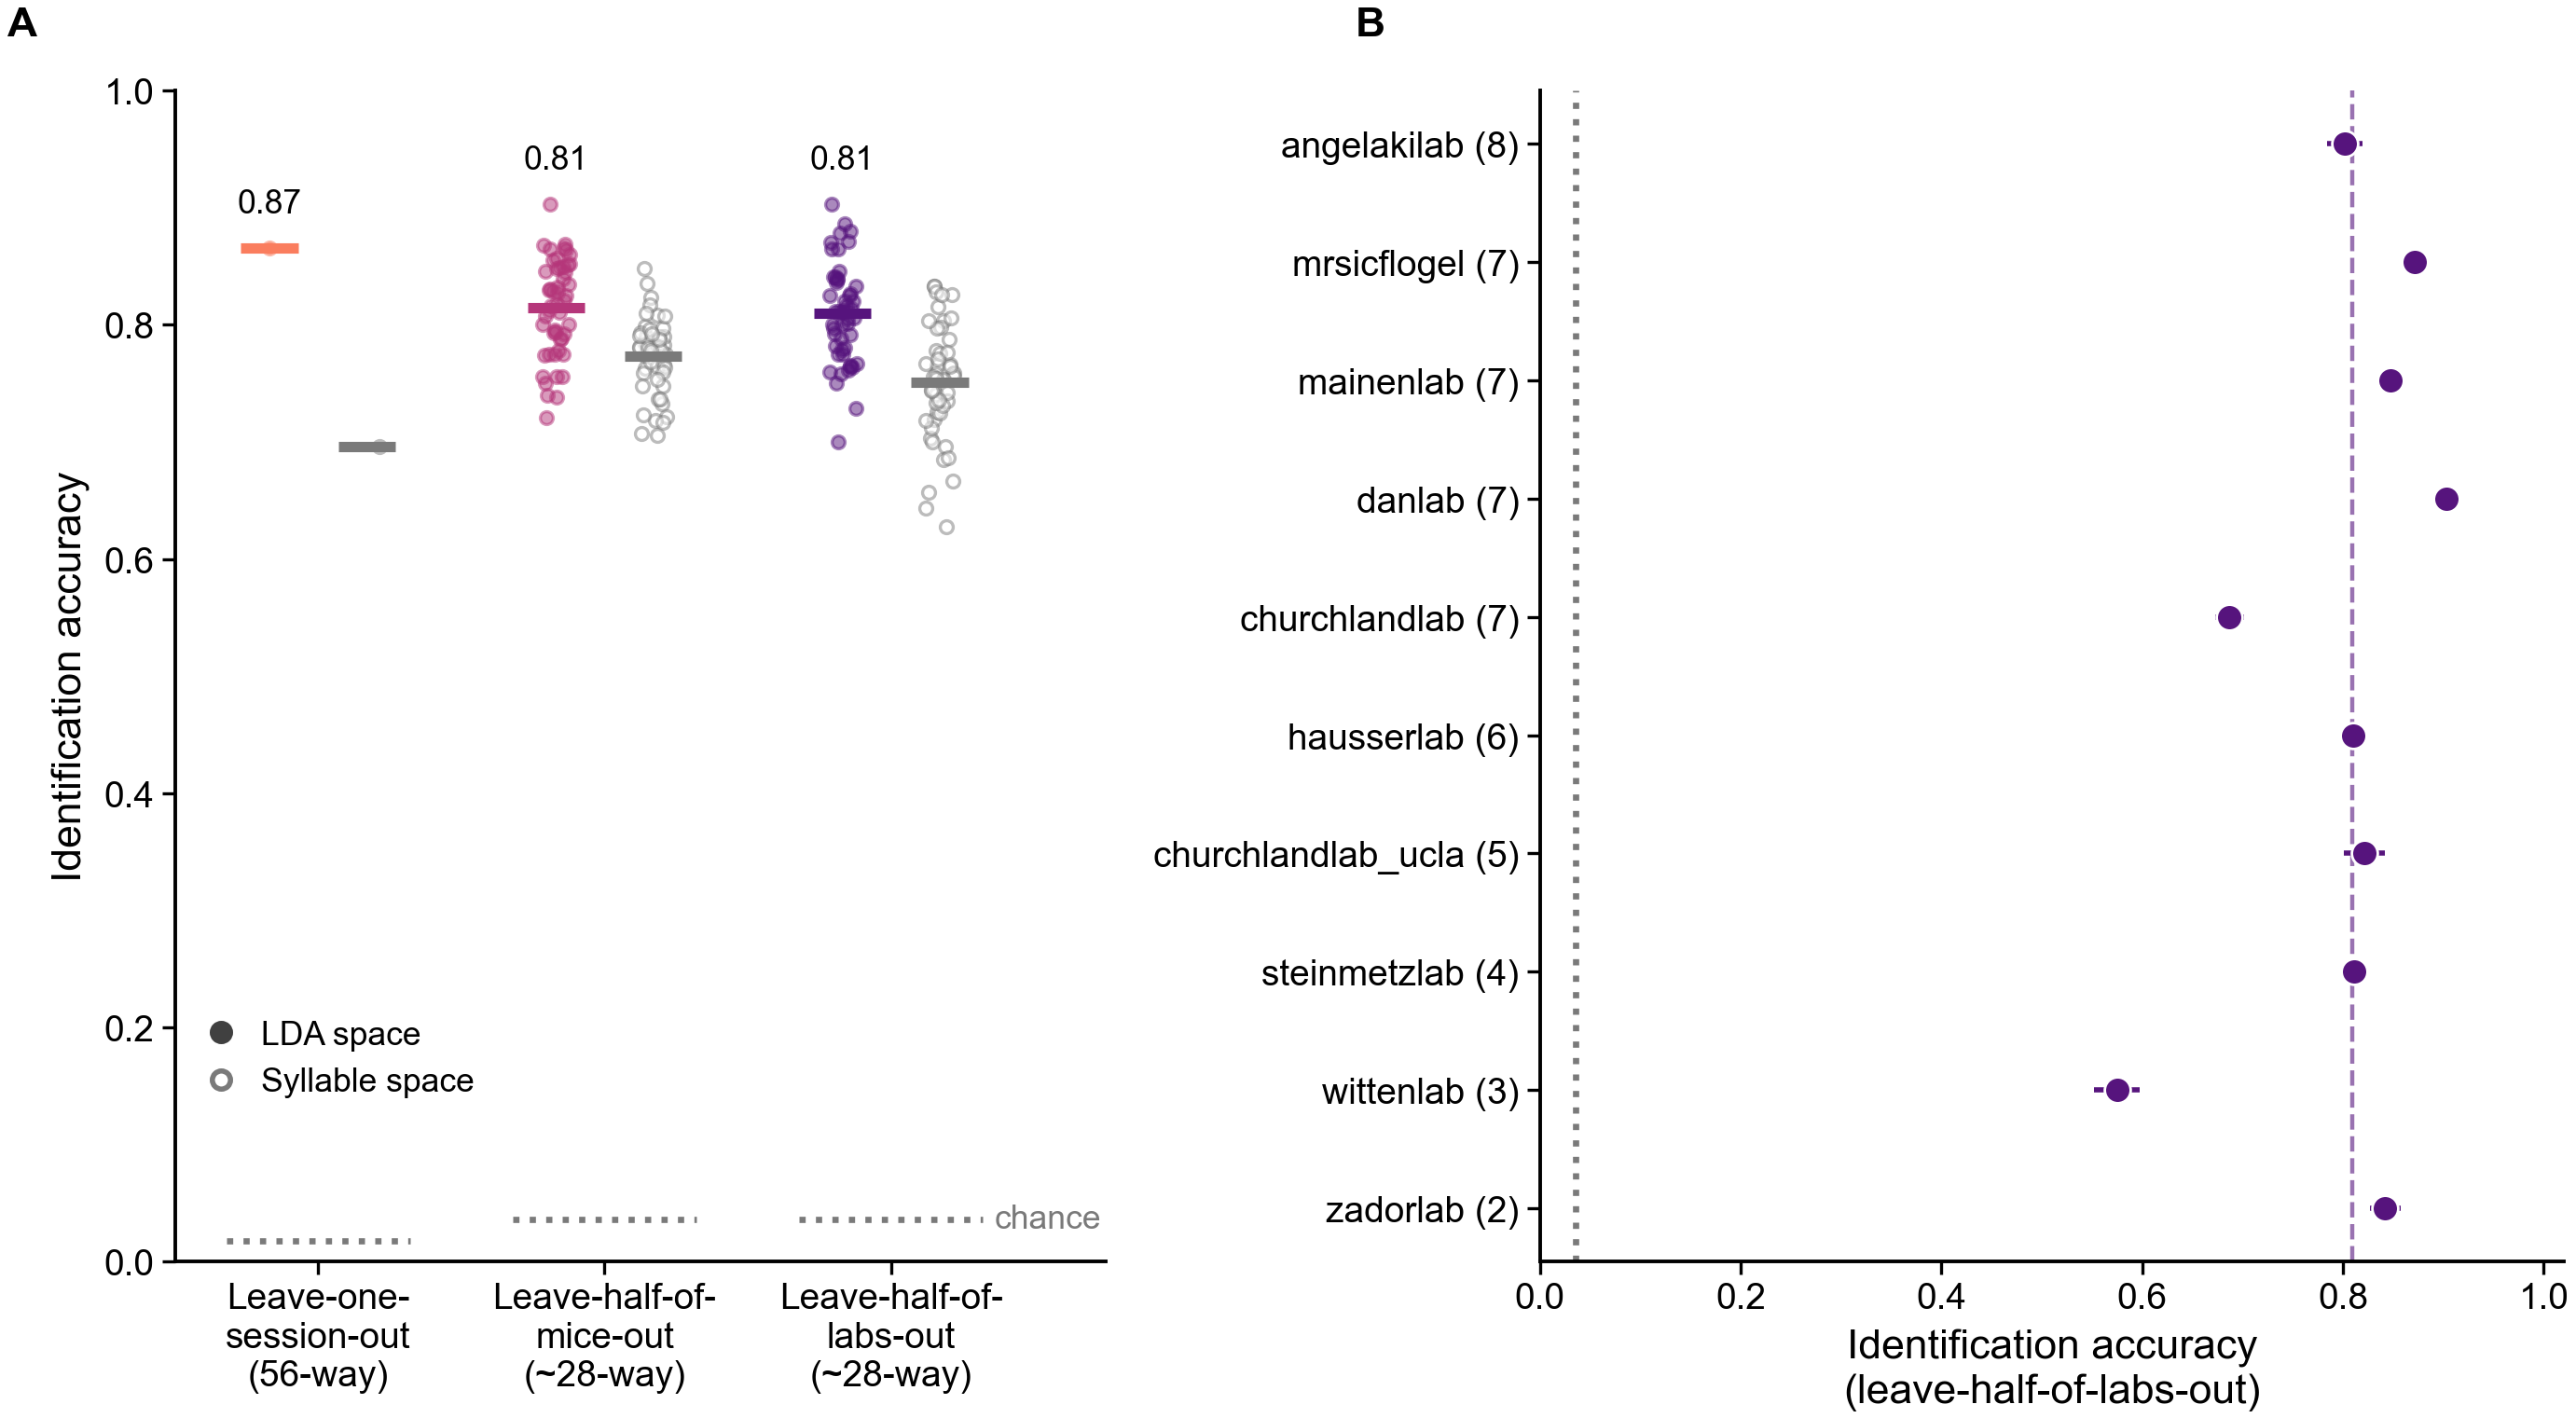

per lab (mean, SEM over splits; n splits with the lab held out):
                     mean    sem  n_splits
lab                                       
zadorlab            0.842  0.015        19
wittenlab           0.575  0.023        22
steinmetzlab        0.811  0.013        29
churchlandlab_ucla  0.821  0.021        25
hausserlab          0.811  0.012        26
churchlandlab       0.687  0.014        26
danlab              0.903  0.010        27
mainenlab           0.847  0.011        25
mrsicflogel         0.872  0.014        25
angelakilab         0.802  0.018        21


In [10]:
TESTS = [('loso', 'Leave-one-\nsession-out', f'{N_MICE}-way'),
         ('mice', 'Leave-half-of-\nmice-out', f'~{round(1 / HALF["mice"]["chance"])}-way'),
         ('labs', 'Leave-half-of-\nlabs-out', f'~{round(1 / HALF["labs"]["chance"])}-way')]
RESULTS = {'loso': {**LOSO, 'chance': 1 / N_MICE}, 'mice': HALF['mice'], 'labs': HALF['labs']}
# One hue darkening with how much is unseen -- the tests are ORDERED, so a sequential ramp
# carries that order rather than three unrelated categorical hues.
TEST_COLOR = dict(zip(['loso', 'mice', 'labs'],
                      [ps.SEQUENTIAL_CMAP(v) for v in (0.75, 0.45, 0.15)]))
fs_small = plt.rcParams['font.size'] * 0.8

w, h = ps.SIZES[ps.MODE]['double']
fig, (axA, axB) = plt.subplots(1, 2, figsize=(w, h * 1.25),
                               gridspec_kw={'width_ratios': [1, 1.1]})

jit = np.random.default_rng(1)
for xi, (key, _, _) in enumerate(TESTS):
    res = RESULTS[key]
    for name, dx, ec, fc in (('lda', -0.17, TEST_COLOR[key], TEST_COLOR[key]),
                             ('syllable', 0.17, ps.NEUTRAL, 'white')):
        v = res[name]
        axA.plot(xi + dx + jit.uniform(-0.05, 0.05, len(v)), v, 'o', ms=2.5, alpha=0.5,
                 mec=ec, mfc=fc, mew=0.6, zorder=3)
        axA.hlines(v.mean(), xi + dx - 0.1, xi + dx + 0.1, color=ec, lw=2, zorder=4)
    axA.text(xi - 0.17, res['lda'].max() + 0.025, f'{res["lda"].mean():.2f}', ha='center',
             va='bottom', fontsize=fs_small)
    axA.hlines(res['chance'], xi - 0.32, xi + 0.32, color=ps.NEUTRAL, ls=':', lw=1.2)
axA.text(2.36, RESULTS['labs']['chance'], 'chance', ha='left', va='center',
         color=ps.NEUTRAL, fontsize=fs_small)
axA.set_xticks(range(3))
axA.set_xticklabels([f'{lbl}\n({way})' for _, lbl, way in TESTS])
axA.set_xlim(-0.5, 2.75)
axA.set_ylim(0, 1)
axA.set_ylabel('Identification accuracy')
from matplotlib.lines import Line2D
axA.legend(handles=[Line2D([], [], marker='o', ls='', mec='0.25', mfc='0.25',
                           label='LDA space'),
                    Line2D([], [], marker='o', ls='', mec=ps.NEUTRAL, mfc='white',
                           label='Syllable space')],
           loc='lower left', bbox_to_anchor=(0.0, 0.12), frameon=False, fontsize=fs_small)

# ---- B: per lab, leave-half-of-labs-out -------------------------------------------
labs_df = half[half['test'] == 'labs']
per_split_lab = labs_df.groupby(['lab', 'split'])['correct'].mean()
lab_mean = per_split_lab.groupby('lab').mean().loc[labs_by_size]
lab_sem = (per_split_lab.groupby('lab').std() /
           np.sqrt(per_split_lab.groupby('lab').size())).loc[labs_by_size]
yy = np.arange(len(lab_mean))
axB.errorbar(lab_mean, yy, xerr=lab_sem, fmt='o', ms=5, color=TEST_COLOR['labs'],
             ecolor=TEST_COLOR['labs'], elinewidth=1, capsize=0, mec='white', mew=0.5)
axB.axvline(HALF['labs']['chance'], color=ps.NEUTRAL, ls=':', lw=1.2)
axB.axvline(HALF['labs']['lda'].mean(), color=TEST_COLOR['labs'], ls='--', lw=0.8,
            alpha=0.6)
axB.set_yticks(yy)
axB.set_yticklabels([f'{L} ({n_by_lab[L]})' for L in lab_mean.index])
axB.set_xlim(0, 1.02)
axB.set_xlabel('Identification accuracy\n(leave-half-of-labs-out)')

for ax, letter in ((axA, 'A'), (axB, 'B')):
    ax.text(-0.18, 1.04, letter, transform=ax.transAxes, fontweight='bold', va='bottom')
fig.tight_layout()
ps.savefig(fig, 'lda_generalisation_shrinkage', svg=True)
plt.show()
print('per lab (mean, SEM over splits; n splits with the lab held out):')
print(pd.DataFrame({'mean': lab_mean, 'sem': lab_sem,
                    'n_splits': per_split_lab.groupby('lab').size().loc[labs_by_size]})
      .round(3))

## Figure 2: how many dimensions does individuality occupy?

**A. Held-out variance explained by mouse, per discriminant** (leave-one-session-out). For
component k, $R^2_k = 1 - \sum (z_k - \mu_{\text{own},k})^2 / \sum (z_k - \bar\mu_k)^2$
over held-out sessions: how much of a new session's position on that axis its mouse predicts.
This is the coefficient of determination of a one-way model, mouse identity predicting the
coordinate, computed out-of-sample (a cross-validated or predictive R²). It is analogous to
an out-of-sample repeatability, and it can be negative: on an axis that does not generalise,
the mouse's training centroid predicts a new session worse than the grand mean does. The grey band is the same quantity on axes fit
to shuffled labels, i.e. directions chosen without knowing who is who. Components are ordered
by eigenvalue within each fold; near-tied ones swap between folds, so read the envelope.

**B. Identification using only the first k dimensions.** LDA space for the three tests, and
the first k principal components (label-blind, variance-ranked) for leave-one-session-out.
Dots mark the smallest k reaching 90% of each curve's maximum. The half-split curves stop at
25: their training half has at least 26 mice, so 25 discriminants. Chance differs between
tests (1/56 vs ~1/28), but is below 0.04 for all.

**C. Distance from a held-out session to each mouse centroid** (leave-one-session-out, all
discriminants): its own mouse, its labmates, and mice from other labs.

**D. Where the errors go.** The share of misidentified sessions assigned to a labmate,
against the share expected if the wrong answer were a random candidate. In the half-split
tests every candidate is equally unseen, so this baseline is fair.

In [11]:
def cv_r2(res2, dev2):
    return 1 - res2.sum(axis=0) / dev2.sum(axis=0)


r2 = cv_r2(loso['res2'], loso['dev2'])
boot = np.random.default_rng(2)
_B = [boot.integers(0, len(loso['res2']), len(loso['res2'])) for _ in range(500)]
true_lo, true_hi = np.percentile([cv_r2(loso['res2'][b], loso['dev2'][b]) for b in _B],
                                 [2.5, 97.5], axis=0)
shuf_lo, shuf_hi = np.percentile([cv_r2(loso['res2_shuf'][b], loso['dev2_shuf'][b])
                                  for b in _B], [2.5, 97.5], axis=0)
N_SIG = int(np.argmax(true_lo <= shuf_hi)) if (true_lo <= shuf_hi).any() else K
print(f'discriminants whose held-out R^2 clears the shuffled band, counted from LD1 until '
      f'the first that does not: {N_SIG}')

# np.mean, not nanmean: a dimension is plotted only where EVERY fold defines it, so the
# tail of a curve is never an average over the few folds that happen to have more mice
CURVES = {'loso': loso['curve'].astype(float).mean(axis=0)}
for test in ('mice', 'labs'):
    CURVES[test] = np.stack(half.loc[half['test'] == test, 'curve']).mean(axis=0)
CURVE_PCA = loso['curve_pca'].astype(float).mean(axis=0)


def k_at(curve, frac=0.9):
    c = curve[~np.isnan(curve)]
    return int(np.argmax(c >= frac * c.max())) + 1


for key, c in CURVES.items():
    print(f'{key:5s} LD1 alone {c[0]:.2f}, 5 dims {c[4]:.2f}, 10 dims {c[9]:.2f}, '
          f'90% of max at k = {k_at(c)}')
print(f'PCA   5 dims {CURVE_PCA[4]:.2f}, 10 dims {CURVE_PCA[9]:.2f}, max {CURVE_PCA.max():.2f}')

classes_all = MICE
same_mouse = classes_all[None, :] == y[:, None]
same_lab = lab_of_mouse.loc[classes_all].to_numpy()[None, :] == lab_arr[:, None]
D = loso_dist
dist_groups = {'Own mouse': D[same_mouse],
               'Labmates': D[same_lab & ~same_mouse],
               'Other labs': D[~same_lab]}

wrong = ~loso['correct']
_t = y[loso['test_idx']][wrong]
ERR = {'loso': (np.mean(lab_of_mouse.loc[_t].to_numpy()
                        == lab_of_mouse.loc[loso['pred'][wrong]].to_numpy()),
                np.mean([(n_by_lab[lab_of_mouse[m]] - 1) / (N_MICE - 1) for m in _t]),
                int(wrong.sum()))}
for test in ('mice', 'labs'):
    d = half[(half['test'] == test) & ~half['correct']]
    ERR[test] = (np.mean(d['lab'] == d['pred_lab']),
                 np.mean(d['n_labmates'] / (d['k'] - 1)), len(d))
for key, (o, e, nw) in ERR.items():
    print(f'{key:5s} {o:.2f} of {nw} errors go to a labmate (random-candidate expectation '
          f'{e:.2f})')

discriminants whose held-out R^2 clears the shuffled band, counted from LD1 until the first that does not: 7
loso  LD1 alone 0.08, 5 dims 0.55, 10 dims 0.70, 90% of max at k = 15
mice  LD1 alone 0.12, 5 dims 0.53, 10 dims 0.70, 90% of max at k = 12
labs  LD1 alone 0.12, 5 dims 0.50, 10 dims 0.69, 90% of max at k = 13
PCA   5 dims 0.39, 10 dims 0.58, max 0.71
loso  0.31 of 35 errors go to a labmate (random-candidate expectation 0.09)
mice  0.23 of 1195 errors go to a labmate (random-candidate expectation 0.09)
labs  0.42 of 1233 errors go to a labmate (random-candidate expectation 0.19)


not saved (ps.SAVE_FIGURES is False): figures/lda_dimensionality_shrinkage_02-10-2026.png, figures/lda_dimensionality_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


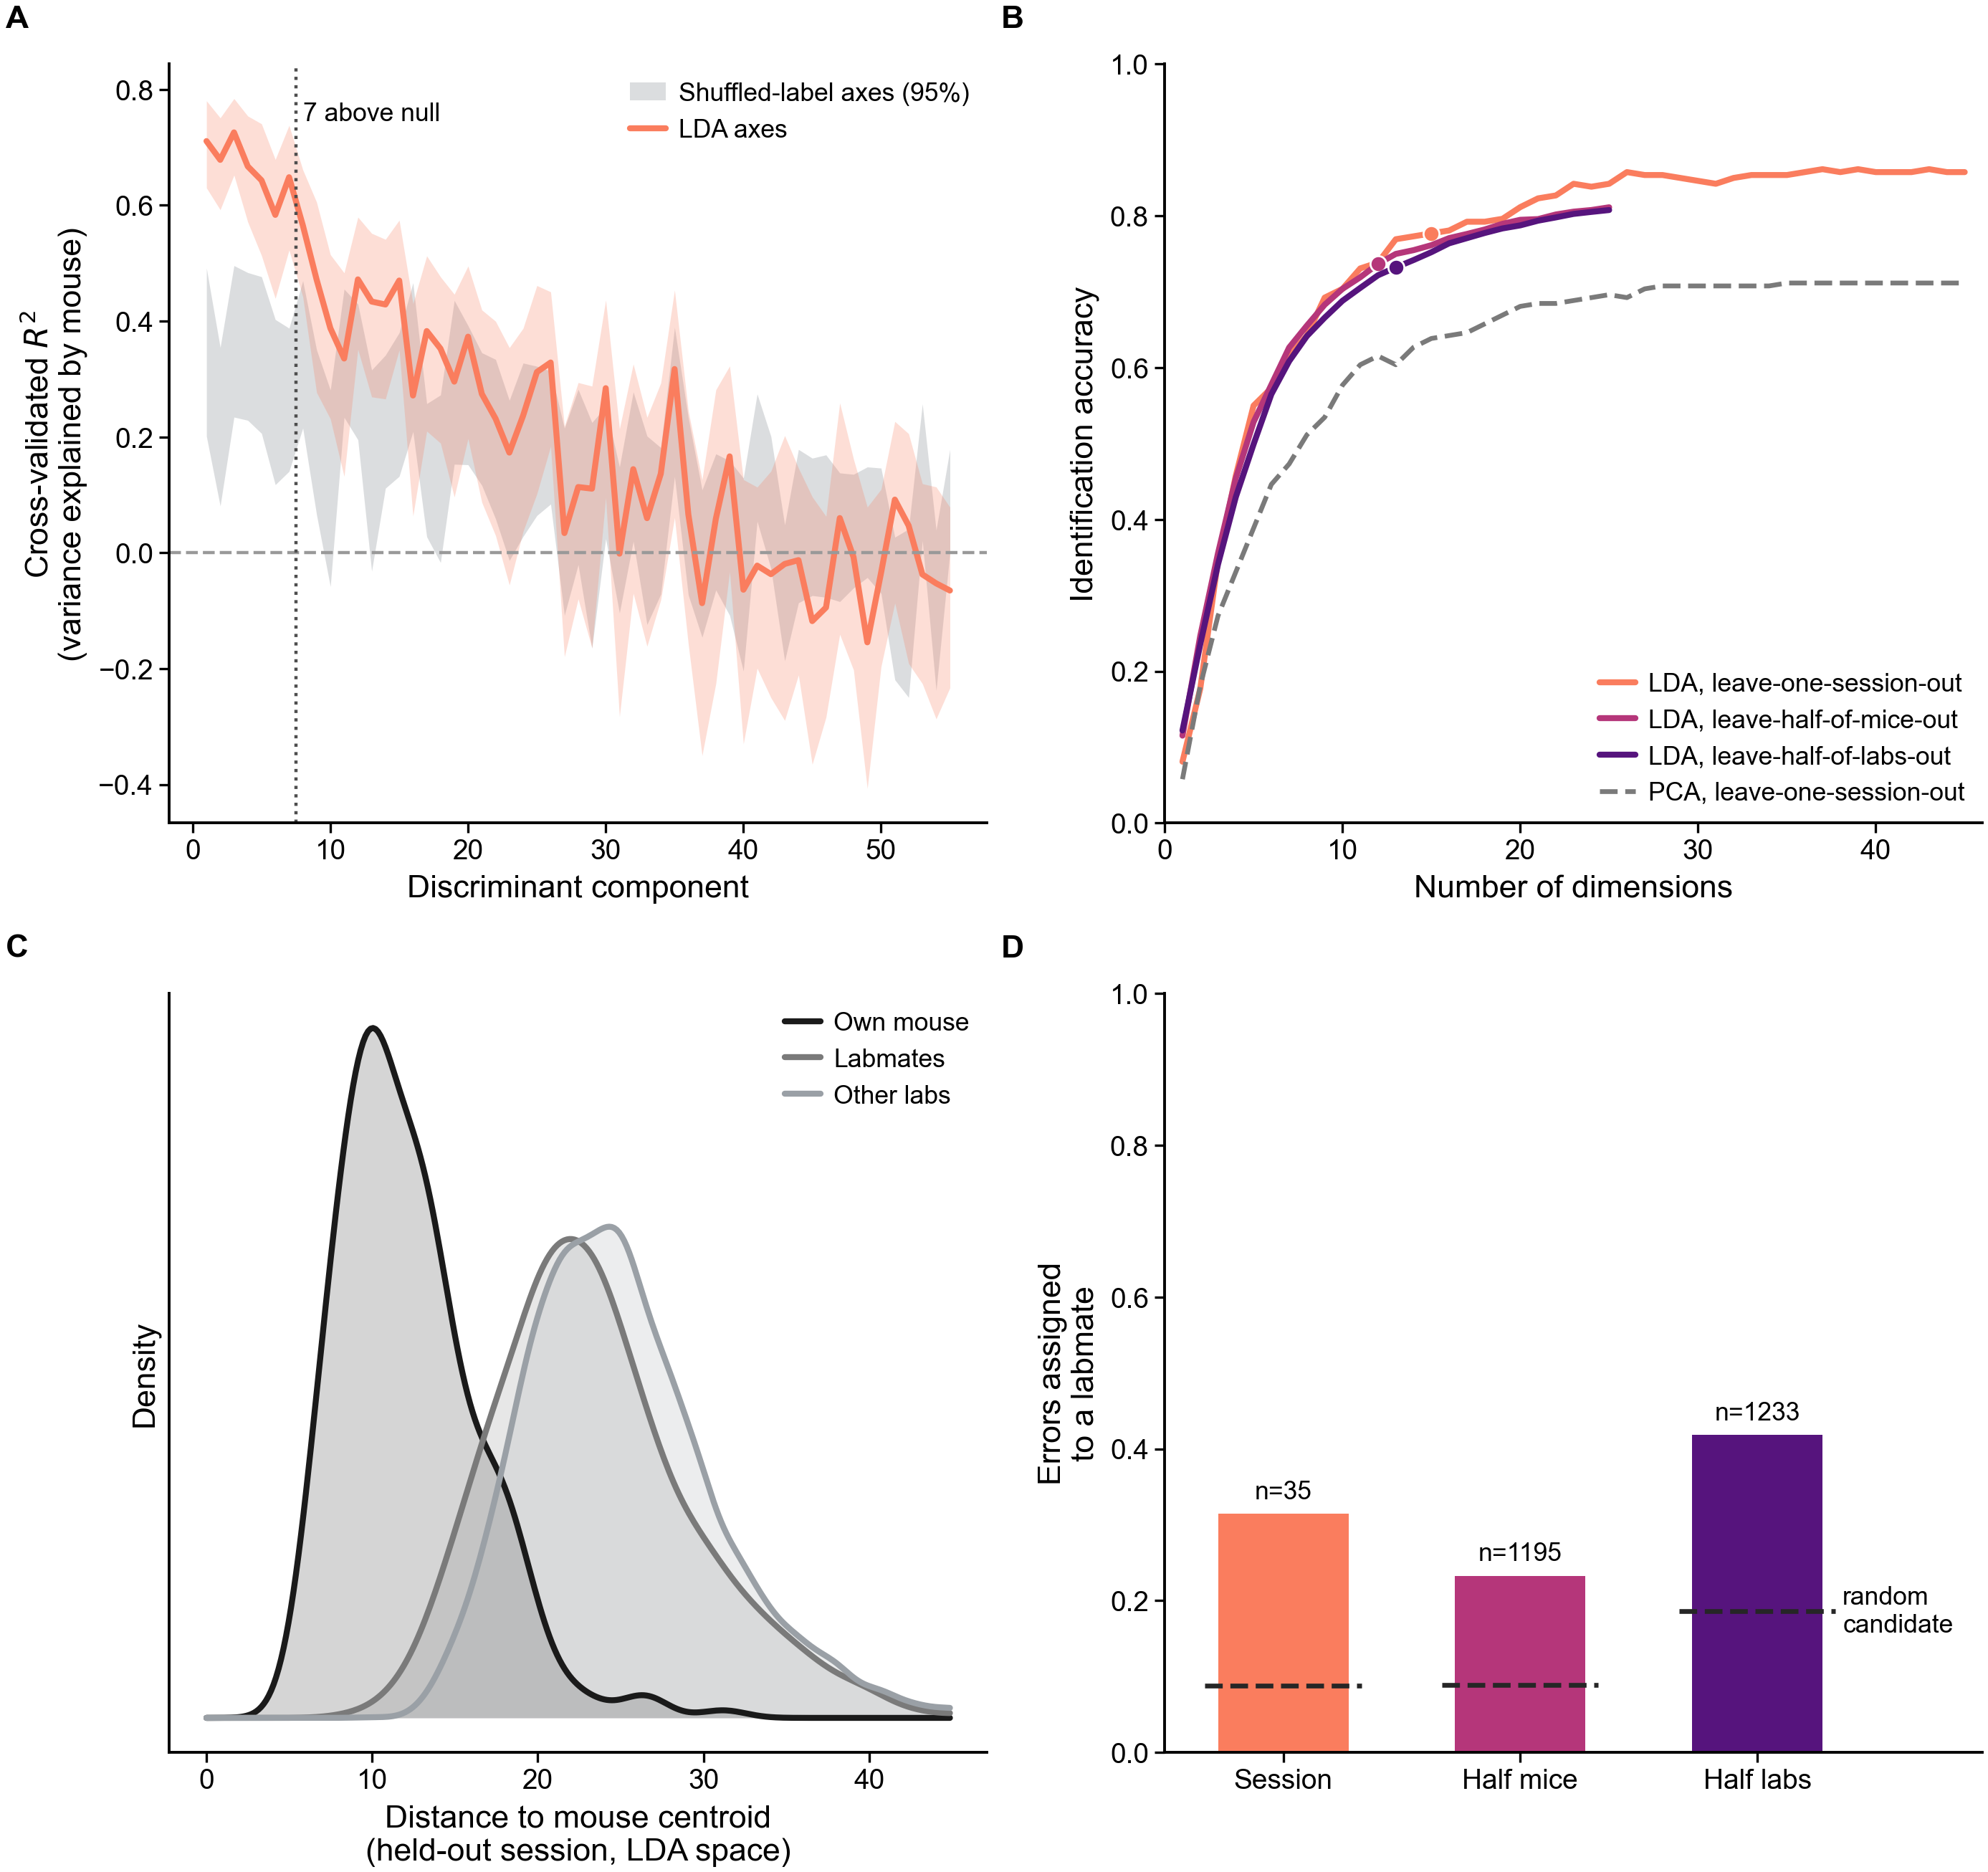

In [12]:
from scipy.stats import gaussian_kde

w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(2, 2, figsize=(w, h * 2.1))
(axA, axB), (axC, axD) = axs

# ---- A ----------------------------------------------------------------------------
kk = np.arange(1, K + 1)
axA.fill_between(kk, shuf_lo, shuf_hi, color=ps.NULL_BAND, alpha=0.35, lw=0,
                 label='Shuffled-label axes (95%)')
axA.fill_between(kk, true_lo, true_hi, color=TEST_COLOR['loso'], alpha=0.25, lw=0)
axA.plot(kk, r2, color=TEST_COLOR['loso'], lw=1.5, label='LDA axes')
axA.axhline(0, color='0.6', ls='--', lw=0.8)
axA.axvline(N_SIG + 0.5, color='0.3', ls=':', lw=0.8)
axA.text(N_SIG + 1, 0.95, f'{N_SIG} above null', transform=axA.get_xaxis_transform(),
         fontsize=fs_small, va='top')
axA.set_xlabel('Discriminant component')
axA.set_ylabel('Cross-validated $R^2$\n(variance explained by mouse)')
axA.legend(frameon=False, fontsize=fs_small, loc='upper right')

# ---- B ----------------------------------------------------------------------------
dims = np.arange(1, MAX_DIMS_PLOT + 1)
# a legend, not end labels: the half-split curves stop at 25 right under the session curve
for key, label in (('loso', 'LDA, leave-one-session-out'), ('mice', 'LDA, leave-half-of-mice-out'),
                   ('labs', 'LDA, leave-half-of-labs-out')):
    c = CURVES[key][:MAX_DIMS_PLOT]
    axB.plot(dims, c, color=TEST_COLOR[key], lw=1.5, label=label)
    k90 = k_at(CURVES[key])
    axB.plot(k90, c[k90 - 1], 'o', ms=4, color=TEST_COLOR[key], mec='white', mew=0.5)
axB.plot(dims, CURVE_PCA[:MAX_DIMS_PLOT], color=ps.NEUTRAL, lw=1.2, ls='--',
         label='PCA, leave-one-session-out')
axB.legend(frameon=False, fontsize=fs_small, loc='lower right')
axB.set_xlim(0, MAX_DIMS_PLOT + 1)
axB.set_ylim(0, 1)
axB.set_xlabel('Number of dimensions')
axB.set_ylabel('Identification accuracy')

# ---- C ----------------------------------------------------------------------------
grid = np.linspace(0, np.percentile(D, 99.5), 300)
for (name, v), col in zip(dist_groups.items(), ['0.1', ps.NEUTRAL, ps.NULL_BAND]):
    dens = gaussian_kde(v)(grid)
    axC.fill_between(grid, dens, color=col, alpha=0.18, lw=0)
    axC.plot(grid, dens, color=col, lw=1.5, label=name)
axC.legend(frameon=False, fontsize=fs_small, loc='upper right')
axC.set_xlabel('Distance to mouse centroid\n(held-out session, LDA space)')
axC.set_ylabel('Density')
axC.set_yticks([])

# ---- D ----------------------------------------------------------------------------
keys = ['loso', 'mice', 'labs']
xx = np.arange(3)
axD.bar(xx, [ERR[k_][0] for k_ in keys], width=0.55, color=[TEST_COLOR[k_] for k_ in keys])
axD.hlines([ERR[k_][1] for k_ in keys], xx - 0.33, xx + 0.33, color='0.15', ls='--', lw=1.2)
axD.text(2.36, ERR['labs'][1], 'random\ncandidate', fontsize=fs_small, va='center')
for xi, k_ in enumerate(keys):
    axD.text(xi, ERR[k_][0] + 0.02, f'n={ERR[k_][2]}', ha='center', fontsize=fs_small)
axD.set_xticks(xx)
axD.set_xticklabels(['Session', 'Half mice', 'Half labs'])
axD.set_xlim(-0.5, 2.95)
axD.set_ylim(0, 1)
axD.set_ylabel('Errors assigned\nto a labmate')

for ax, letter in zip(axs.flat, 'ABCD'):
    ax.text(-0.2, 1.04, letter, transform=ax.transAxes, fontweight='bold', va='bottom')
fig.tight_layout()
ps.savefig(fig, 'lda_dimensionality_shrinkage', svg=True)
plt.show()

## Figure 3: syllables vs. task measures

Can mice be told apart as well from the standard **task measures** an IBL analysis reports?
The six raw measures, one number each per session, built in
`non_emerging/session_metric_individuality.ipynb` (its session table is read here):

| measure | |
|---|---|
| accuracy | easy trials (contrast > 0.5) |
| log reaction time | session median, `log1p` |
| log trial elongation | session median, `log1p` |
| block bias | P(right \| p(left)=0.2) − P(right \| p(left)=0.8) at 0% contrast |
| choice bias | signed, and its magnitude |

The three GLM-HMM engagement measures are **excluded**: that model is fit one mouse at a time,
so between-mouse differences in them are part fit. Trial count is excluded because it
measures scheduling more than the mouse.

**The dimensionality problem, and the fair comparison.** Syllable space has 360 features and
the task data 6. So "which identifies better" mixes *which data carries more identity* with
*which has more numbers*. Panel A matches the budget: each source gets **k input features
per session**, and the LDA is fit on those. For the syllables that is **PCA, then LDA**: the
first k principal components of the training sessions (label-free, fit inside each fold),
for k = 1…10. That is the best compact summary of the movement data, matched against the
task measures, which are a hand-designed compact summary with k = 6.

Panel B gives the totals, including whether the task measures add anything to the
syllables.

**Protocol.** Everything is identical across feature sets: the same cohort (sessions with
both data types, mice with ≥ 2 such sessions), leave-one-session-out, a training cap of
`N_PER_MOUSE` sessions per mouse, and shrinkage chosen by nested CV *separately for each
feature set and each k*. Six features and 360 need very different regularisation.

In [13]:
import glob
import re

TASK_MEASURES = ['correct', 'log_reaction', 'log_elongation', 'bias',
                 'signed_choice_bias', 'choice_bias']
TASK_LABEL = {'correct': 'accuracy', 'log_reaction': 'log RT', 'log_elongation': 'log elong.',
              'bias': 'block bias', 'signed_choice_bias': 'choice bias',
              'choice_bias': '|choice bias|'}
K_MAX = 10
N_REPEATS_TASK = N_REPEATS
N_REPEATS_BUDGET = 1
# Panel B's totals get the full repeats; panel A's k = 1..10 curve gets one, because it is
# 10 nested fits per fold and its point-to-point step is far larger than the repeat noise
# (about +/-0.01). Raise to 3 for a band; it adds ~10 min per repeat.

# The newest session table session_metric_individuality wrote (dd-mm-yyyy in the name).
_files = glob.glob(str(_root / 'non_emerging' / 'nonemerging_session_metrics_*.csv'))
_date = lambda f: datetime.strptime(re.search(r'(\d{2}-\d{2}-\d{4})', f).group(1), '%d-%m-%Y')
TASK_FILE = max(_files, key=_date)
task_tab = pd.read_csv(TASK_FILE).set_index('session')
print(f'task measures from {pathlib.Path(TASK_FILE).name}')

sessions = all_features.index
_common = sessions.intersection(task_tab.dropna(subset=TASK_MEASURES).index)
_idx = sessions.get_indexer(_common)
_mice = pd.Series(np.asarray(y)[_idx])
_ok = _mice.map(_mice.value_counts() >= 2).to_numpy()   # LOSO needs another session
T_IDX = _idx[_ok]
XS = X[T_IDX]
XT = task_tab.loc[sessions[T_IDX], TASK_MEASURES].to_numpy(float)
XT = (XT - XT.mean(axis=0)) / XT.std(axis=0)            # cosmetic: LDA is affine-invariant
assert (task_tab.loc[sessions[T_IDX], 'mouse_name'].to_numpy()
        == mouse_names.to_numpy()[T_IDX]).all(), 'the two tables disagree about a mouse'
yT = pd.factorize(np.asarray(y)[T_IDX])[0]
nT = len(yT)
CHANCE_T = 1 / len(np.unique(yT))
print(f'cohort: {nT} sessions, {len(np.unique(yT))} mice (of {n} / {N_MICE} in the LDA cohort); '
      f'chance {CHANCE_T:.3f}')

task measures from nonemerging_session_metrics_01-10-2026.csv
cohort: 231 sessions, 52 mice (of 260 / 56 in the LDA cohort); chance 0.019


In [14]:
def nested_predict(F, tr, t, rng):
    """Inner-CV shrinkage on the training sessions, balanced draw, predict session t."""
    s = select_shrinkage(F[tr], yT[tr], rng)
    sel = tr[balanced_draw(yT[tr], rng)]
    return fit_lda(F[sel], yT[sel], s).predict(F[t:t + 1])[0] == yT[t]


def totals_fold(key):
    r_, t = key
    rng = fold_rng(11, r_, t)
    tr = np.setdiff1d(np.arange(nT), t)
    return {'task': nested_predict(XT, tr, t, rng),
            'syllables': nested_predict(XS, tr, t, rng),
            'both': nested_predict(np.hstack([XS, XT]), tr, t, rng)}


def budget_fold(key):
    """Matched input budget: syllables reduced to their first k PCs, then LDA, k = 1..K_MAX."""
    r_, t = key
    rng = fold_rng(13, r_, t)
    tr = np.setdiff1d(np.arange(nT), t)
    Z = PCA(K_MAX).fit(XS[tr]).transform(XS)       # label-free, training sessions only
    return [nested_predict(Z[:, :k], tr, t, rng) for k in range(1, K_MAX + 1)]


_t0 = datetime.now()
_tot = pmap(totals_fold, [(r_, t) for r_ in range(N_REPEATS_TASK) for t in range(nT)])
TOTALS = {k: np.array([r[k] for r in _tot]).reshape(N_REPEATS_TASK, nT).mean(axis=1)
          for k in ('task', 'syllables', 'both')}
_bud = np.array(pmap(budget_fold, [(r_, t) for r_ in range(N_REPEATS_BUDGET)
                                     for t in range(nT)]))
BUDGET_PCA_REP = _bud.reshape(N_REPEATS_BUDGET, nT, K_MAX).mean(axis=1)  # (repeats, K_MAX)
BUDGET_PCA = BUDGET_PCA_REP.mean(axis=0)
print(f'{(datetime.now() - _t0).seconds} s')

for k_, lbl in (('task', f'task measures ({len(TASK_MEASURES)})'),
                ('syllables', f'syllables ({XS.shape[1]})'),
                ('both', f'syllables + task ({XS.shape[1] + len(TASK_MEASURES)})')):
    print(f'{lbl:28s} {TOTALS[k_].mean():.3f} +/- {TOTALS[k_].std():.3f}')
_k = len(TASK_MEASURES)
print(f'\nmatched budget, k = {_k}: task measures {TOTALS["task"].mean():.3f}   '
      f'syllables PCA-{_k} -> LDA {BUDGET_PCA[_k - 1]:.3f}')
print('syllables PCA-k -> LDA, k = 1..10:', np.round(BUDGET_PCA, 3))
_first = int(np.argmax(BUDGET_PCA > TOTALS['task'].mean())) + 1
print(f'syllables need {_first} PC(s) to beat all {_k} task measures')

472 s
task measures (6)            0.190 +/- 0.000
syllables (360)              0.857 +/- 0.000
syllables + task (366)       0.883 +/- 0.000

matched budget, k = 6: task measures 0.190   syllables PCA-6 -> LDA 0.528
syllables PCA-k -> LDA, k = 1..10: [0.095 0.139 0.32  0.377 0.485 0.528 0.593 0.61  0.68  0.675]
syllables need 3 PC(s) to beat all 6 task measures


not saved (ps.SAVE_FIGURES is False): figures/lda_syllables_vs_task_shrinkage_02-10-2026.png, figures/lda_syllables_vs_task_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


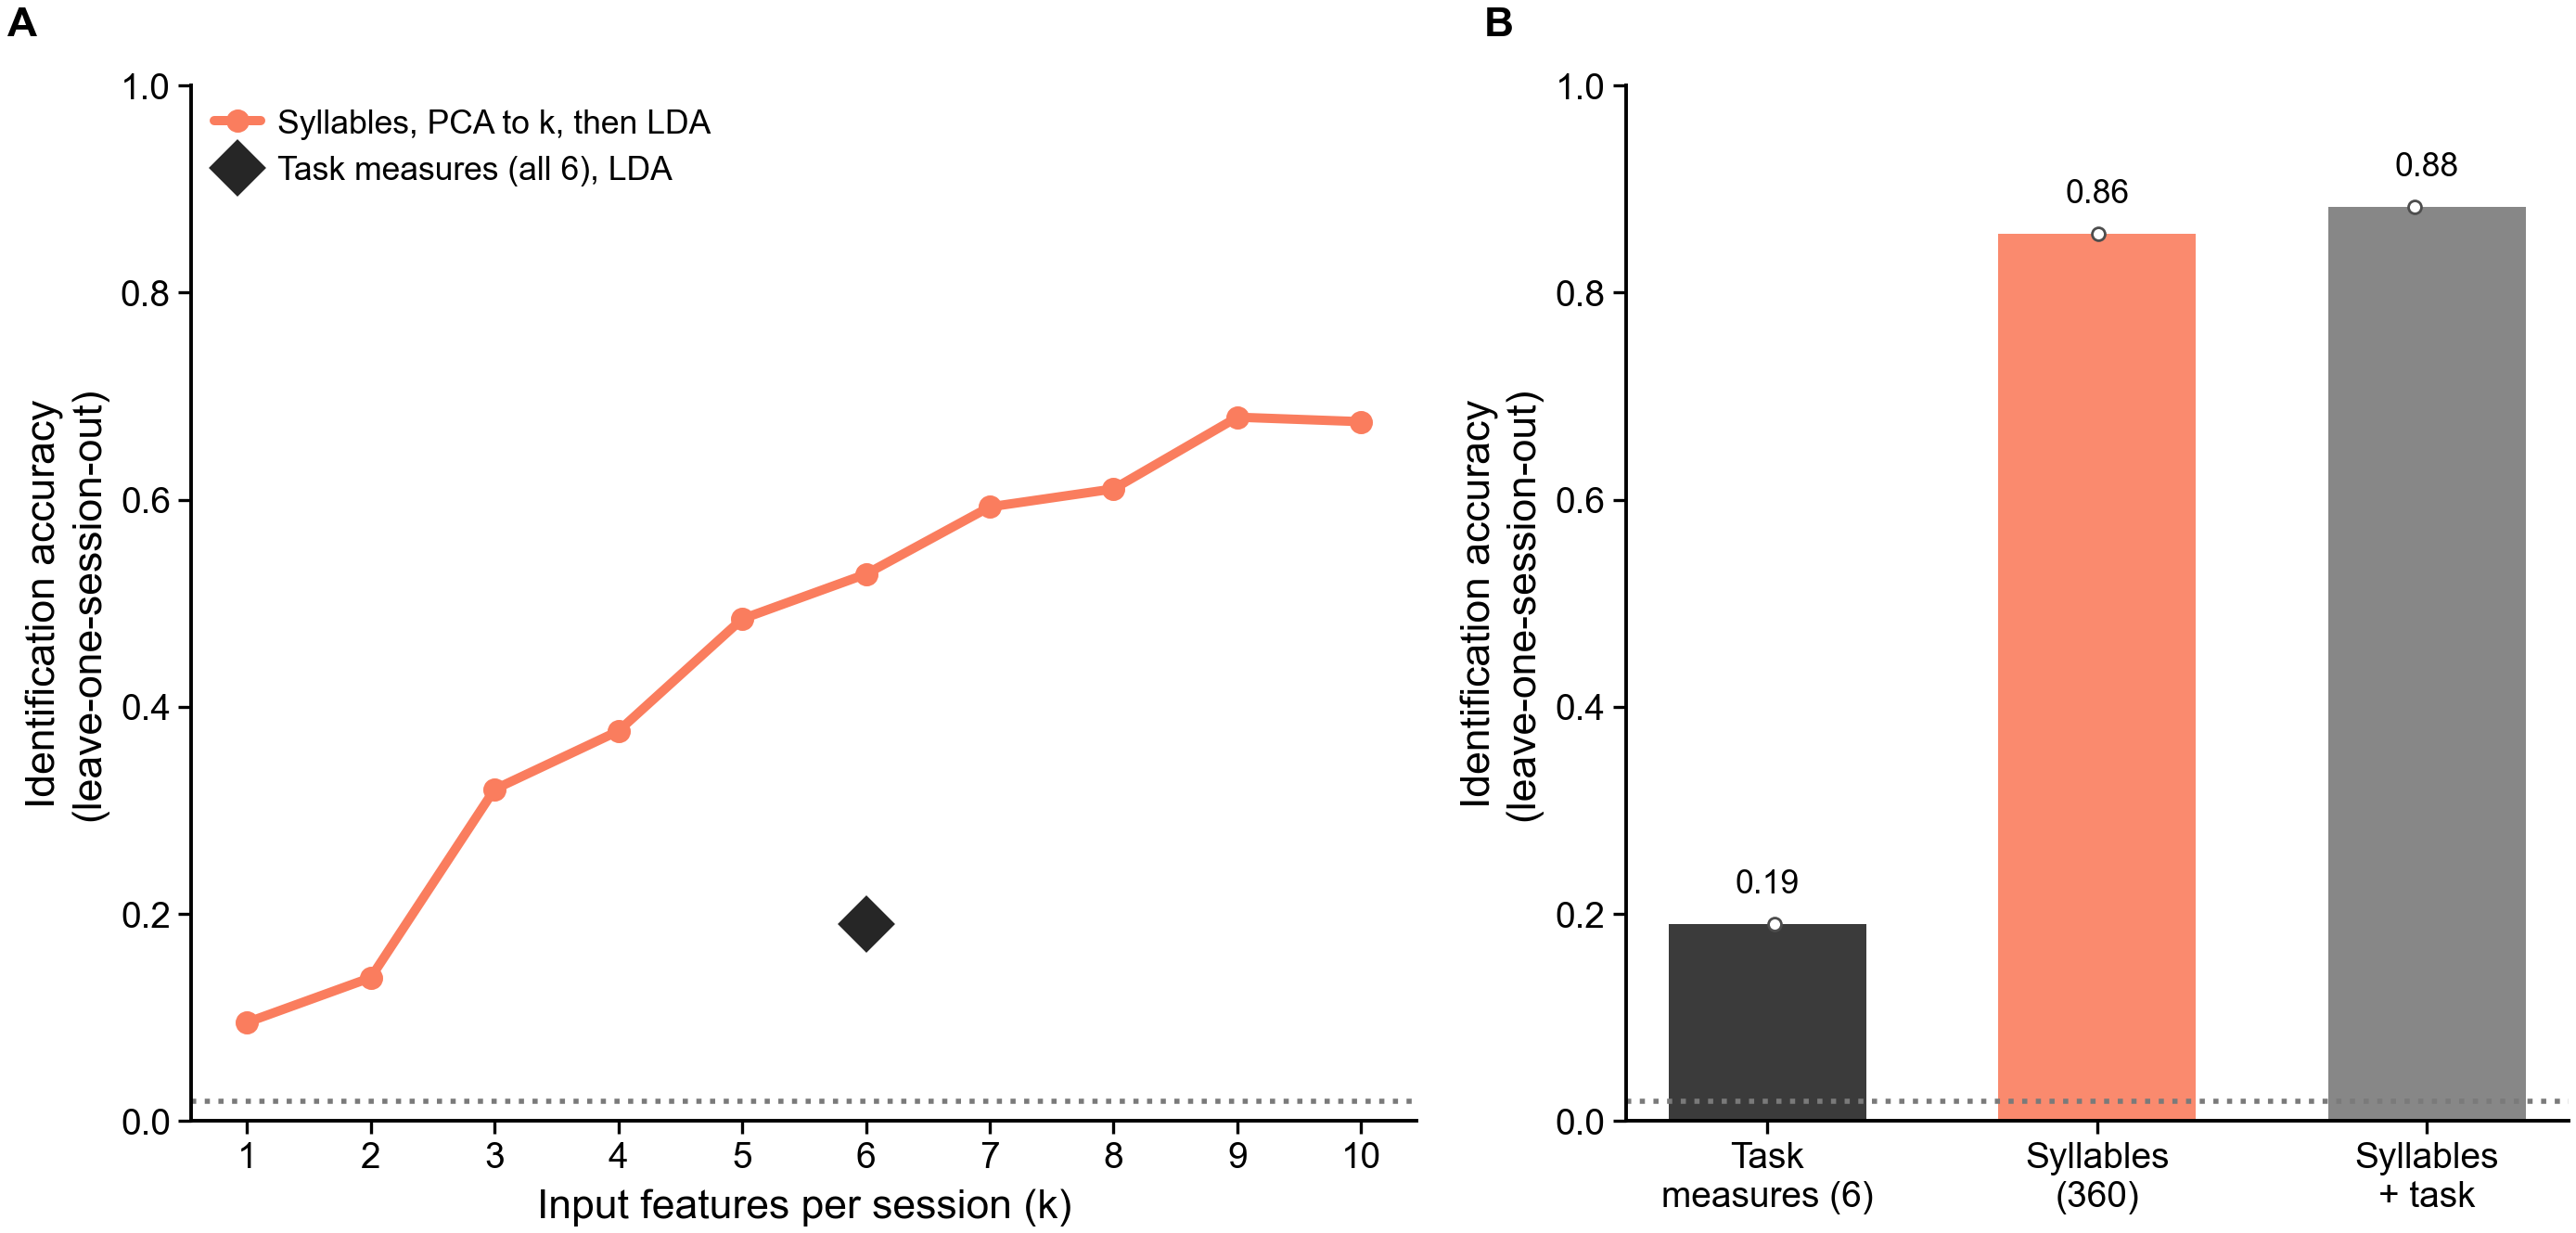

In [15]:
TASK_INK, SYL_INK = '0.15', TEST_COLOR['loso']
w, h = ps.SIZES[ps.MODE]['double']
fig, (axA, axB) = plt.subplots(1, 2, figsize=(w, h * 1.1),
                               gridspec_kw={'width_ratios': [1.3, 1]})

kk = np.arange(1, K_MAX + 1)
if N_REPEATS_BUDGET > 1:
    axA.fill_between(kk, BUDGET_PCA_REP.min(axis=0), BUDGET_PCA_REP.max(axis=0),
                     color=SYL_INK, alpha=0.2, lw=0)
axA.plot(kk, BUDGET_PCA, color=SYL_INK, lw=1.8, marker='o', ms=3.5,
         label='Syllables, PCA to k, then LDA')
axA.errorbar(len(TASK_MEASURES), TOTALS['task'].mean(),
             yerr=[[TOTALS['task'].mean() - TOTALS['task'].min()],
                   [TOTALS['task'].max() - TOTALS['task'].mean()]],
             fmt='D', ms=7, color=TASK_INK,
             label=f'Task measures (all {len(TASK_MEASURES)}), LDA', zorder=5)
axA.axhline(CHANCE_T, color=ps.NEUTRAL, ls=':', lw=1)
axA.set_xticks(kk)
axA.set_xlabel('Input features per session (k)')
axA.set_ylabel('Identification accuracy\n(leave-one-session-out)')
axA.set_ylim(0, 1)
axA.legend(frameon=False, fontsize=fs_small, loc='upper left')

names = [('task', f'Task\nmeasures ({len(TASK_MEASURES)})', TASK_INK),
         ('syllables', f'Syllables\n({XS.shape[1]})', SYL_INK),
         ('both', 'Syllables\n+ task', ps.NEUTRAL)]
for xi, (k_, lbl, col) in enumerate(names):
    v = TOTALS[k_]
    axB.bar(xi, v.mean(), width=0.6, color=col, alpha=0.9)
    axB.plot(np.full(len(v), xi) + np.random.default_rng(xi).uniform(-0.08, 0.08, len(v)),
             v, 'o', ms=2.5, color='white', mec='0.3', mew=0.5)
    axB.text(xi, v.mean() + 0.03, f'{v.mean():.2f}', ha='center', fontsize=fs_small)
axB.axhline(CHANCE_T, color=ps.NEUTRAL, ls=':', lw=1)
axB.set_xticks(range(len(names)))
axB.set_xticklabels([lbl for _, lbl, _ in names])
axB.set_ylim(0, 1)
axB.set_ylabel('Identification accuracy\n(leave-one-session-out)')

for ax, letter in ((axA, 'A'), (axB, 'B')):
    ax.text(-0.15, 1.04, letter, transform=ax.transAxes, fontweight='bold', va='bottom')
fig.tight_layout()
ps.savefig(fig, 'lda_syllables_vs_task_shrinkage', svg=True)
plt.show()

## Supplementary: stability of the individual LD axes

Is LD1 (or LDk) a stable direction, or an arbitrary rotation inside a stable subspace? The
**reference** is the embedding `lda_shrinkage` saves with its default `EMBEDDING_WEIGHTING =
'mouse'`: all sessions, every mouse counted once in the between-mouse scatter, no balanced
draw (`fit_mouse_weighted` below is copied from that notebook). It is refit under three
perturbations, at the same shrinkage:

| perturbation | refits | the question |
|---|---|---|
| **drop sessions** | `N_STABILITY`, each keeping a random 80% of every mouse's sessions (min. 2) | does the axis depend on which days were recorded? |
| **drop one mouse** | 56, one per mouse | does any single mouse define the axis? |
| **drop one lab** | 10, one per lab | does any single lab define the axis? (LD1 is lab-confounded) |

All 260 sessions are projected through the reference and each refit, and per dimension k:

* **same axis** |r|: reference LDk against refit LDk, sign-free.
* **best match** |r|: reference LDk against whichever refit axis matches it best. High best
  match with low same-axis means the axis survives but swaps rank with near-tied neighbours.
* **subspace**: how much of the reference top-k space the refit top-k space reproduces (mean
  squared canonical correlation, 1 = identical). High subspace with low same-axis means you
  should interpret the subspace, not individual axes.

Compared up to the smallest refit's discriminant count (dropping the largest lab leaves 48
mice, so 47 dimensions).

In [16]:
from scipy import linalg


def fit_mouse_weighted(Xt, yt, shrinkage):
    """Equal-mouse-weight LDA, copied from lda_shrinkage -- keep the two in sync."""
    classes = np.unique(yt)
    M = np.stack([Xt[yt == c].mean(axis=0) for c in classes])
    grand = M.mean(axis=0)
    Sb = np.cov((M - grand).T, bias=True)
    R = Xt - M[np.searchsorted(classes, yt)]
    Sw = R.T @ R / (len(Xt) - len(classes))
    Sw = (1 - shrinkage) * Sw + shrinkage * np.trace(Sw) / len(Sw) * np.eye(len(Sw))
    evals, evecs = linalg.eigh(Sb, Sw)
    order = np.argsort(evals)[::-1][:len(classes) - 1]
    return evecs[:, order], grand, evals[order]


EMBED_SHRINKAGE = 0.5
# lda_shrinkage picks this by CV with the one-SE rule; it chose 0.5 on 01-10-2026. Set it to
# whatever that notebook printed if its data or knobs change.
_W_ref, _g_ref, _ = fit_mouse_weighted(X, y, EMBED_SHRINKAGE)
Z_ref = (X - _g_ref) @ _W_ref


def stability_refit(key):
    scheme, i = key
    if scheme == 'sessions':
        rng = fold_rng(9, i)
        idx = np.concatenate([
            rng.choice(s_, max(2, int(round(STABILITY_SESSIONS * len(s_)))), replace=False)
            for s_ in (np.where(y == m)[0] for m in MICE)])
    elif scheme == 'mouse':
        idx = np.where(y != MICE[i])[0]
    else:
        idx = np.where(lab_arr != labs_by_size[i])[0]
    W_i, g_i, _ = fit_mouse_weighted(X[idx], y[idx], EMBED_SHRINKAGE)
    Z = (X - g_i) @ W_i
    Kc = Z.shape[1]
    A = (Z_ref[:, :Kc] - Z_ref[:, :Kc].mean(0)) / Z_ref[:, :Kc].std(0)
    B = (Z - Z.mean(0)) / Z.std(0)
    R = np.abs(A.T @ B) / len(A)              # |r| between every reference and refit axis
    sub = np.empty(Kc)
    for k_ in range(1, Kc + 1):
        qa, _ = np.linalg.qr(A[:, :k_])
        qb, _ = np.linalg.qr(B[:, :k_])
        sub[k_ - 1] = np.mean(np.linalg.svd(qa.T @ qb, compute_uv=False) ** 2)
    return scheme, i, pad(np.diag(R)), pad(R.max(axis=1)), pad(sub)


SCHEMES = {'sessions': N_STABILITY, 'mouse': N_MICE, 'lab': len(labs_by_size)}
_st = pmap(stability_refit, [(s_, i) for s_, n_ in SCHEMES.items() for i in range(n_)])
STAB = {s_: {name: np.stack([r[j] for r in _st if r[0] == s_]) for j, name in
             ((2, 'same axis'), (3, 'best match'), (4, 'subspace'))} for s_ in SCHEMES}
K_STAB = int(min(np.sum(~np.isnan(STAB[s_]['same axis']), axis=1).min() for s_ in SCHEMES))

stab_table = pd.concat({
    s_: pd.DataFrame({f'{name} {stat}': fn(STAB[s_][name][:, :K_STAB], axis=0)
                      for name in ('same axis', 'best match', 'subspace')
                      for stat, fn in (('median', np.median),
                                       ('min', np.min))},
                     index=pd.Index([f'LD{k_ + 1}' for k_ in range(K_STAB)], name='dimension'))
    for s_ in SCHEMES}, axis=1)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)

lab_drop_ld1 = pd.Series([r[2][0] for r in _st if r[0] == 'lab'],
                         index=[labs_by_size[r[1]] for r in _st if r[0] == 'lab'],
                         name='LD1 same-axis |r| with this lab dropped').sort_values()
print(lab_drop_ld1.round(3).to_string())
print('\nper-dimension stability, median and worst refit, all three perturbations:')
stab_table.round(3)

hausserlab            0.921
angelakilab           0.930
danlab                0.930
churchlandlab         0.955
churchlandlab_ucla    0.981
mrsicflogel           0.986
steinmetzlab          0.990
wittenlab             0.994
mainenlab             0.995
zadorlab              0.997

per-dimension stability, median and worst refit, all three perturbations:


sessions                                                 \
          same axis median same axis min best match median best match min   
dimension                                                                   
LD1                  0.953         0.098             0.953          0.749   
LD2                  0.893         0.019             0.893          0.640   
LD3                  0.575         0.069             0.780          0.533   
LD4                  0.664         0.038             0.836          0.597   
LD5                  0.806         0.060             0.819          0.480   
LD6                  0.761         0.047             0.793          0.561   
LD7                  0.692         0.026             0.749          0.536   
LD8                  0.806         0.035             0.813          0.505   
LD9                  0.709         0.017             0.769          0.539   
LD10                 0.554         0.001             0.715          0.468   
LD11                 0.559         0.010             0.737          0.512   
LD12                 0.457         0.003             0.675          0.459   
LD13                 0.415         0.005             0.690          0.491   
LD14                 0.385         0.016             0.643          0.417   
LD15                 0.336         0.002             0.628          0.432   
LD16                 0.356         0.000             0.621          0.445   
LD17                 0.296         0.018             0.617          0.351   
LD18                 0.352         0.014             0.619          0.415   
LD19                 0.471         0.002             0.641          0.403   
LD20                 0.342         0.009             0.638          0.430   
LD21                 0.328         0.029             0.604          0.464   
LD22                 0.313         0.002             0.572          0.392   
LD23                 0.259         0.001             0.560          0.378   
LD24                 0.347         0.002             0.579          0.408   
LD25                 0.260         0.005             0.543          0.417   
LD26                 0.298         0.001             0.620          0.450   
LD27                 0.253         0.009             0.554          0.391   
LD28                 0.314         0.001             0.538          0.378   
LD29                 0.396         0.004             0.607          0.410   
LD30                 0.304         0.004             0.541          0.391   
LD31                 0.340         0.011             0.550          0.396   
LD32                 0.235         0.004             0.562          0.386   
LD33                 0.243         0.003             0.539          0.368   
LD34                 0.330         0.010             0.537          0.396   
LD35                 0.339         0.001             0.547          0.354   
LD36                 0.280         0.009             0.554          0.378   
LD37                 0.265         0.000             0.550          0.366   
LD38                 0.212         0.010             0.510          0.360   
LD39                 0.266         0.004             0.525          0.380   
LD40                 0.266         0.001             0.510          0.381   
LD41                 0.292         0.013             0.553          0.391   
LD42                 0.296         0.001             0.487          0.323   
LD43                 0.268         0.001             0.542          0.392   
LD44                 0.280         0.003             0.506          0.358   
LD45                 0.206         0.000             0.519          0.351   
LD46                 0.199         0.004             0.503          0.374   
LD47                 0.222         0.001             0.482          0.298   

                                                  mouse                \
          subspace median subspace min same axis median same axis min   
dimension            

not saved (ps.SAVE_FIGURES is False): figures/lda_axis_stability_shrinkage_02-10-2026.png, figures/lda_axis_stability_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


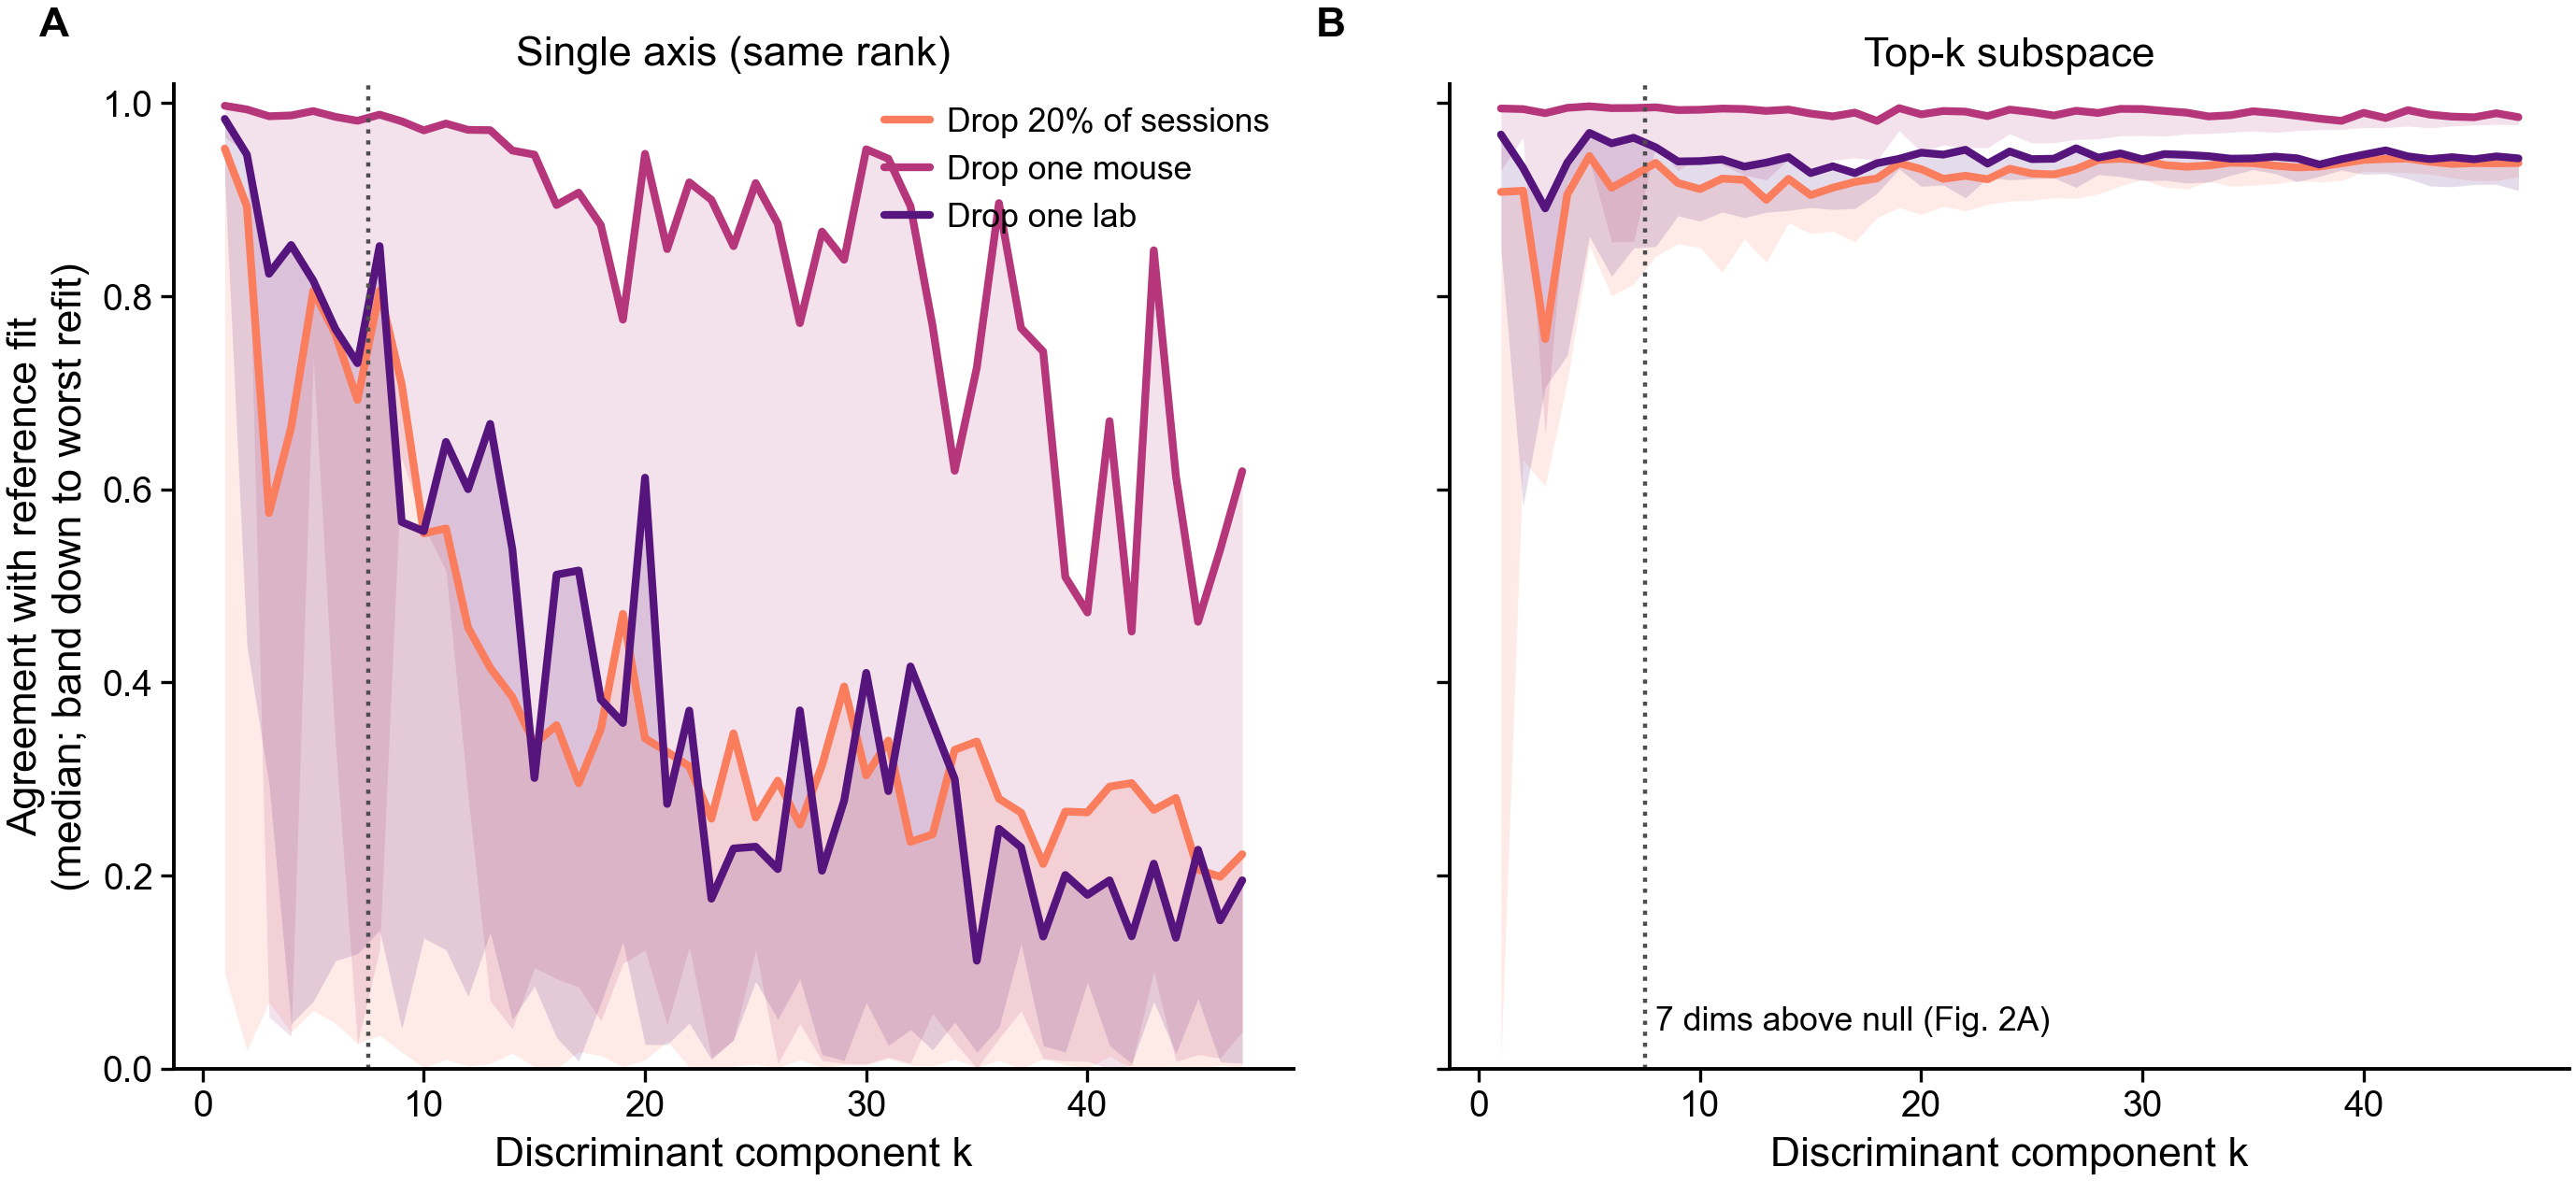

sessions LD1: 0.95  LD2: 0.89  LD3: 0.58  LD5: 0.81  LD10: 0.55 | top-10 subspace 0.91
mouse LD1: 1.00  LD2: 0.99  LD3: 0.99  LD5: 0.99  LD10: 0.97 | top-10 subspace 0.99
lab LD1: 0.98  LD2: 0.95  LD3: 0.82  LD5: 0.82  LD10: 0.56 | top-10 subspace 0.94


In [17]:
SCHEME_STYLE = {'sessions': ('Drop 20% of sessions', TEST_COLOR['loso']),
                'mouse': ('Drop one mouse', TEST_COLOR['mice']),
                'lab': ('Drop one lab', TEST_COLOR['labs'])}
w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(1, 2, figsize=(w, h * 1.05), sharey=True)
kk = np.arange(1, K_STAB + 1)
for ax, metric, title in ((axs[0], 'same axis', 'Single axis (same rank)'),
                          (axs[1], 'subspace', 'Top-k subspace')):
    for s_, (label, col) in SCHEME_STYLE.items():
        a = STAB[s_][metric][:, :K_STAB]
        ax.fill_between(kk, a.min(axis=0), np.median(a, axis=0), color=col, alpha=0.15, lw=0)
        ax.plot(kk, np.median(a, axis=0), color=col, lw=1.5, label=label)
    ax.axvline(N_SIG + 0.5, color='0.3', ls=':', lw=0.8)
    ax.set_xlabel('Discriminant component k')
    ax.set_title(title, fontsize=plt.rcParams['font.size'])
    ax.set_ylim(0, 1.02)
axs[0].set_ylabel('Agreement with reference fit\n(median; band down to worst refit)')
axs[0].legend(frameon=False, fontsize=fs_small, loc='upper right')
axs[1].text(N_SIG + 1, 0.04, f'{N_SIG} dims above null (Fig. 2A)', fontsize=fs_small)
for ax, letter in zip(axs, 'AB'):
    ax.text(-0.12, 1.04, letter, transform=ax.transAxes, fontweight='bold', va='bottom')
fig.tight_layout()
ps.savefig(fig, 'lda_axis_stability_shrinkage', svg=True)
plt.show()
for s_ in SCHEMES:
    print(s_, '  '.join(f'LD{k_}: {np.median(STAB[s_]["same axis"][:, k_ - 1]):.2f}'
                        for k_ in (1, 2, 3, 5, 10)),
          f'| top-10 subspace {np.median(STAB[s_]["subspace"][:, 9]):.2f}')

## Supplementary: 56-way leave-one-mouse-out and leave-one-lab-out

The intuitive "one out" versions. Train on 55 mice (or on every lab but one), then match each
held-out session among **all 56** mouse centroids: training mice from their training
sessions, held-out mice from their own enrolment sessions. They are not the main result
because of the bias measured by the decoy test below. Unseen mice look alike in a space learned
on other mice, which favours the held-out mouse's own centroid against the 55 seen ones. In
the lab version it also pulls errors toward the equally unseen labmates.

In [18]:
def one_out_fold(key):
    tag, repeat, f, test_mice = key
    test_mice = np.asarray(test_mice)
    rng = fold_rng(tag, repeat, f)
    te_mask = np.isin(y, test_mice)
    tr_full, te = np.where(~te_mask)[0], np.where(te_mask)[0]
    shrink = select_shrinkage(X[tr_full], y[tr_full], rng)
    sel = tr_full[balanced_draw(y[tr_full], rng)]
    mu, sd = X[tr_full].mean(axis=0), X[tr_full].std(axis=0) + 1e-12
    spaces = {'lda': X @ ld_basis(fit_lda(X[sel], y[sel], shrink), len(np.unique(y[sel]))),
              'syllable': (X - mu) / sd}
    rows = []
    for i in te:
        enrol = {}
        for m in test_mice:
            pool = te[(y[te] == m) & (te != i)]
            enrol[m] = rng.choice(pool, min(N_PER_MOUSE, len(pool)), replace=False)
        row = {'tag': tag, 'repeat': repeat, 'session': i, 'mouse': y[i]}
        for name, Z in spaces.items():
            ctr, Mtr = class_centroids(Z[sel], y[sel])
            M = np.vstack([Mtr, np.stack([Z[enrol[m]].mean(axis=0) for m in test_mice])])
            cand = np.concatenate([ctr, test_mice])
            row[name] = cand[np.argmin(((M - Z[i]) ** 2).sum(axis=1))] == y[i]
        rows.append(row)
    return rows


def decoy_fold(d):
    """Hold out A and B; query A against the 54 training centroids + B's. All answers are
    wrong; how often B wins measures the pull between unseen mice."""
    rng = fold_rng(3, d)
    A, B = rng.choice(MICE, 2, replace=False)
    tr_full = np.where(~np.isin(y, [A, B]))[0]
    shrink = select_shrinkage(X[tr_full], y[tr_full], rng, n_folds=1)
    sel = tr_full[balanced_draw(y[tr_full], rng)]
    W = ld_basis(fit_lda(X[sel], y[sel], shrink), N_MICE - 2)
    _, Mtr = class_centroids(X[sel] @ W, y[sel])
    b = np.where(y == B)[0]
    M = np.vstack([Mtr, (X[rng.choice(b, min(N_PER_MOUSE, len(b)), replace=False)] @ W)
                   .mean(axis=0)])
    return [np.argmin(((M - q) ** 2).sum(axis=1)) == len(Mtr) for q in X[y == A] @ W]


_keys = ([(1, r, f, [m]) for r in range(N_REPEATS_ONE_OUT) for f, m in enumerate(MICE)]
         + [(2, r, f, list(lab_of_mouse.index[lab_of_mouse == L]))
            for r in range(N_REPEATS_ONE_OUT) for f, L in enumerate(labs_by_size)])
one_out = pd.DataFrame([r for rows in pmap(one_out_fold, _keys) for r in rows])
decoy = np.concatenate(pmap(decoy_fold, range(N_DECOY)))
DECOY_CHANCE = 1 / (N_MICE - 1)

ONE_OUT = {'loso': {'lda': LOSO['lda'], 'syllable': LOSO['syllable']}}
for tag, key in ((1, 'lomo'), (2, 'lolo')):
    d = one_out[one_out['tag'] == tag]
    ONE_OUT[key] = {nm: by_group(d[nm], d['repeat']) for nm in ('lda', 'syllable')}
for key, res in ONE_OUT.items():
    print(f'{key}  LDA space {res["lda"].mean():.3f}   syllable space '
          f'{res["syllable"].mean():.3f}   (56-way, chance {1 / N_MICE:.3f})')
print(f'decoy: an unseen mouse is picked {decoy.mean():.3f} of the time vs chance '
      f'{DECOY_CHANCE:.3f} ({decoy.mean() / DECOY_CHANCE:.1f}x, {len(decoy)} queries)')

loso  LDA space 0.865   syllable space 0.696   (56-way, chance 0.018)
lomo  LDA space 0.873   syllable space 0.722   (56-way, chance 0.018)
lolo  LDA space 0.860   syllable space 0.713   (56-way, chance 0.018)
decoy: an unseen mouse is picked 0.051 of the time vs chance 0.018 (2.8x, 670 queries)


not saved (ps.SAVE_FIGURES is False): figures/lda_one_out_56way_shrinkage_02-10-2026.png, figures/lda_one_out_56way_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


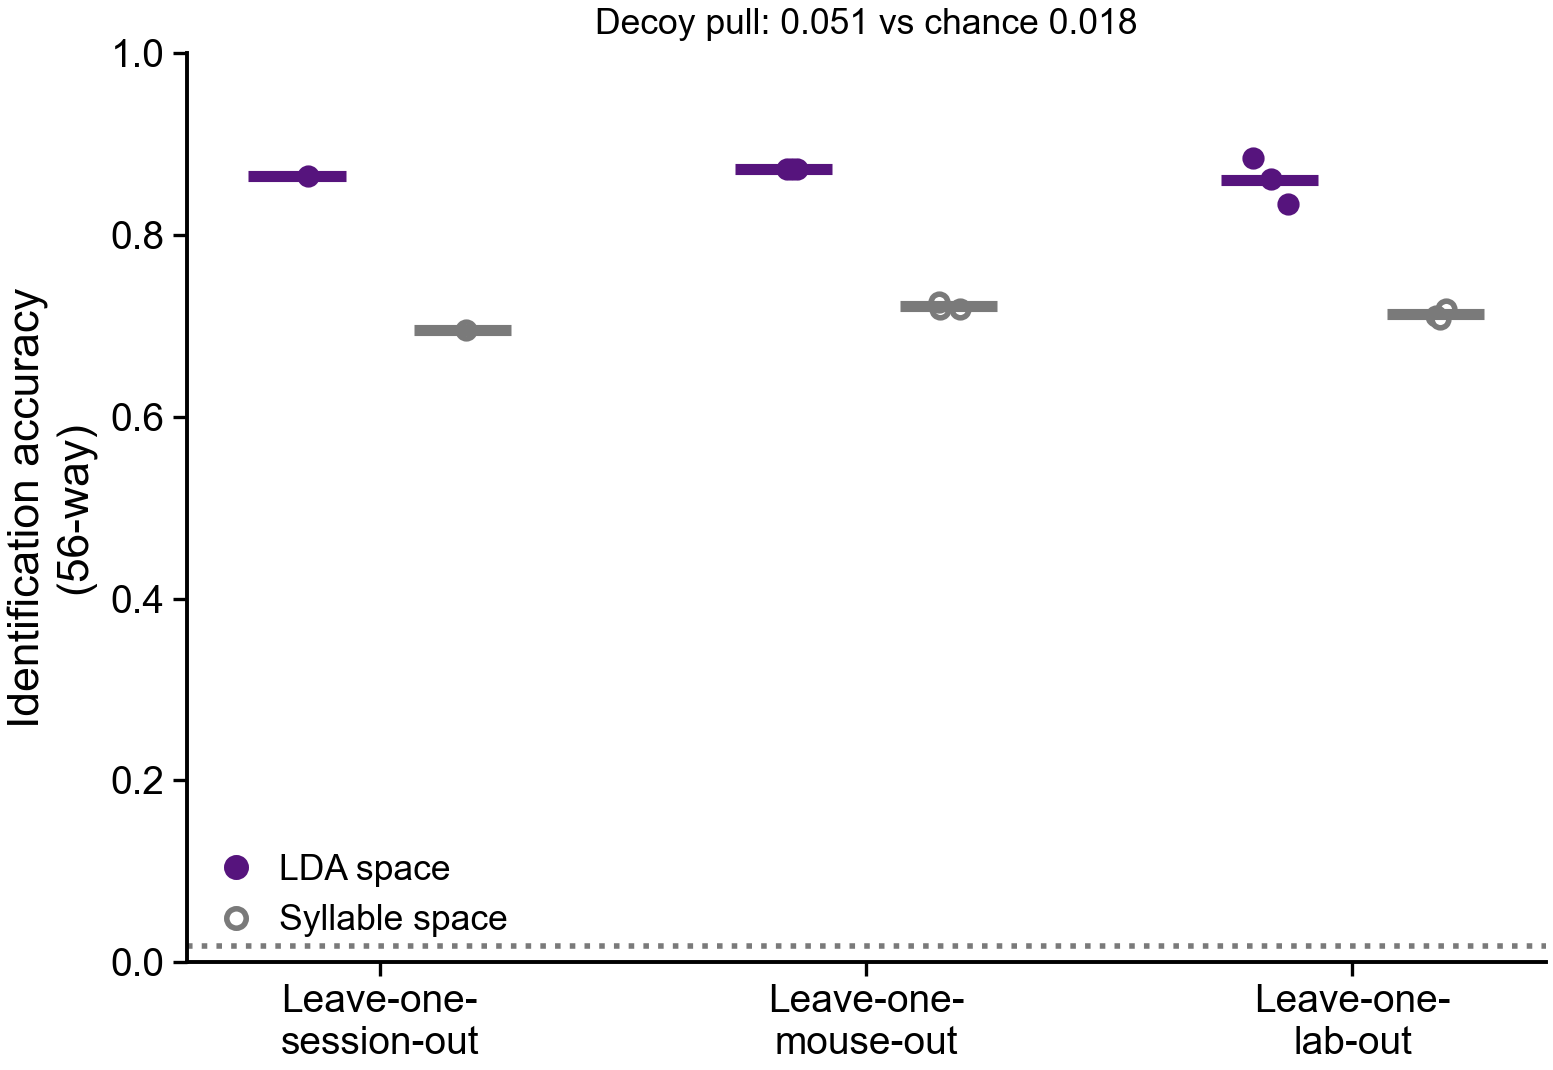

In [19]:
w, h = ps.SIZES[ps.MODE]['single']
fig, ax = plt.subplots(figsize=(w * 1.2, h * 1.2))
labels = [('loso', 'Leave-one-\nsession-out'), ('lomo', 'Leave-one-\nmouse-out'),
          ('lolo', 'Leave-one-\nlab-out')]
for xi, (key, _) in enumerate(labels):
    for name, dx, ec, fc in (('lda', -0.17, TEST_COLOR['labs'], TEST_COLOR['labs']),
                             ('syllable', 0.17, ps.NEUTRAL, 'white')):
        v = ONE_OUT[key][name]
        ax.plot(xi + dx + jit.uniform(-0.04, 0.04, len(v)), v, 'o', ms=3, mec=ec, mfc=fc)
        ax.hlines(v.mean(), xi + dx - 0.1, xi + dx + 0.1, color=ec, lw=2)
ax.axhline(1 / N_MICE, color=ps.NEUTRAL, ls=':', lw=1)
ax.set_xticks(range(3))
ax.set_xticklabels([lbl for _, lbl in labels])
ax.set_ylim(0, 1)
ax.set_ylabel(f'Identification accuracy\n({N_MICE}-way)')
ax.set_title(f'Decoy pull: {decoy.mean():.3f} vs chance {DECOY_CHANCE:.3f}',
             fontsize=fs_small)
ax.legend(handles=[Line2D([], [], marker='o', ls='', mec=TEST_COLOR['labs'],
                          mfc=TEST_COLOR['labs'], label='LDA space'),
                   Line2D([], [], marker='o', ls='', mec=ps.NEUTRAL, mfc='white',
                          label='Syllable space')],
          loc='lower left', frameon=False, fontsize=fs_small)
fig.tight_layout()
ps.savefig(fig, 'lda_one_out_56way_shrinkage', svg=True)
plt.show()

## Supplementary: what the score depends on

All panels are leave-one-session-out with one **fixed** shrinkage (`FIXED_SHRINKAGE`) and no
inner loop. They are descriptive comparisons between settings, not unbiased scores.

* **A. Shrinkage**: how flat the score is across the grid.
* **B. Maximum training sessions per mouse** (2–5). A cap of 1 cannot be fit, since LDA needs
  more sessions than mice. The cap binds only for mice with more sessions than it.
* **C. Trial epoch**: the LDA refit on one epoch's 90 features.
* **D. Syllable channel**: paw, whisking, licking alone.
* **E. Per mouse**: accuracy against the mouse's number of sessions.

In [20]:
def loso_fixed(Xf, shrink=None, cap=N_PER_MOUSE, n_repeats=1):
    shrink = FIXED_SHRINKAGE if shrink is None else shrink

    def one(key):
        r_, t = key
        tr = np.setdiff1d(np.arange(n), t)
        sel = tr[balanced_draw(y[tr], fold_rng(4, r_, t), cap=cap)]
        return fit_lda(Xf[sel], y[sel], shrink).predict(Xf[t:t + 1])[0] == y[t]

    hits = np.array(pmap(one, [(r_, t) for r_ in range(n_repeats) for t in range(n)]))
    return hits.reshape(n_repeats, n).mean(axis=1)


assert set(SYLLABLE_CHANNELS) == {'paw', 'whisk', 'lick'}, \
    'the epoch/channel sweeps assume all three channels are in the design matrix'
PER_STEP = (N_PAW_STATES - 1) + 2
N_STEPS = X.shape[1] // PER_STEP
step_of_col = np.arange(X.shape[1]) // PER_STEP
within_col = np.arange(X.shape[1]) % PER_STEP
steps_per_epoch = N_STEPS // len(EPOCHS)

SWEEP = {}
SWEEP['shrinkage'] = {s: loso_fixed(X, shrink=s) for s in SHRINKAGE_GRID}
SWEEP['cap'] = {c: loso_fixed(X, cap=c) for c in (2, 3, 4, 5)}
SWEEP['epoch'] = {e: loso_fixed(X[:, step_of_col // steps_per_epoch == i])
                  for i, e in enumerate(EPOCHS)}
SWEEP['epoch']['All'] = loso_fixed(X)
SWEEP['channel'] = {
    'Paw': loso_fixed(X[:, within_col < N_PAW_STATES - 1]),
    'Whisk': loso_fixed(X[:, within_col == N_PAW_STATES - 1]),
    'Lick': loso_fixed(X[:, within_col == N_PAW_STATES]),
    'All': SWEEP['epoch']['All'],
}
for k_, d_ in SWEEP.items():
    print(k_, {kk_: round(float(v.mean()), 3) for kk_, v in d_.items()})

per_mouse = (pd.DataFrame({'mouse': y[loso['test_idx']], 'correct': loso['correct']})
             .groupby('mouse')['correct'].mean())
n_sess = pd.Series(y).value_counts().loc[per_mouse.index]

shrinkage {0.05: 0.831, 0.1: 0.846, 0.2: 0.854, 0.3: 0.854, 0.5: 0.838}
cap {2: 0.796, 3: 0.838, 4: 0.869, 5: 0.896}
epoch {'Pre-quiescence': 0.577, 'Quiescence': 0.565, 'Choice': 0.677, 'ITI': 0.719, 'All': 0.838}
channel {'Paw': 0.735, 'Whisk': 0.55, 'Lick': 0.454, 'All': 0.838}


not saved (ps.SAVE_FIGURES is False): figures/lda_supplementary_shrinkage_02-10-2026.png, figures/lda_supplementary_shrinkage_02-10-2026.svg   -- ps.saving(True) to write, or pass save=True


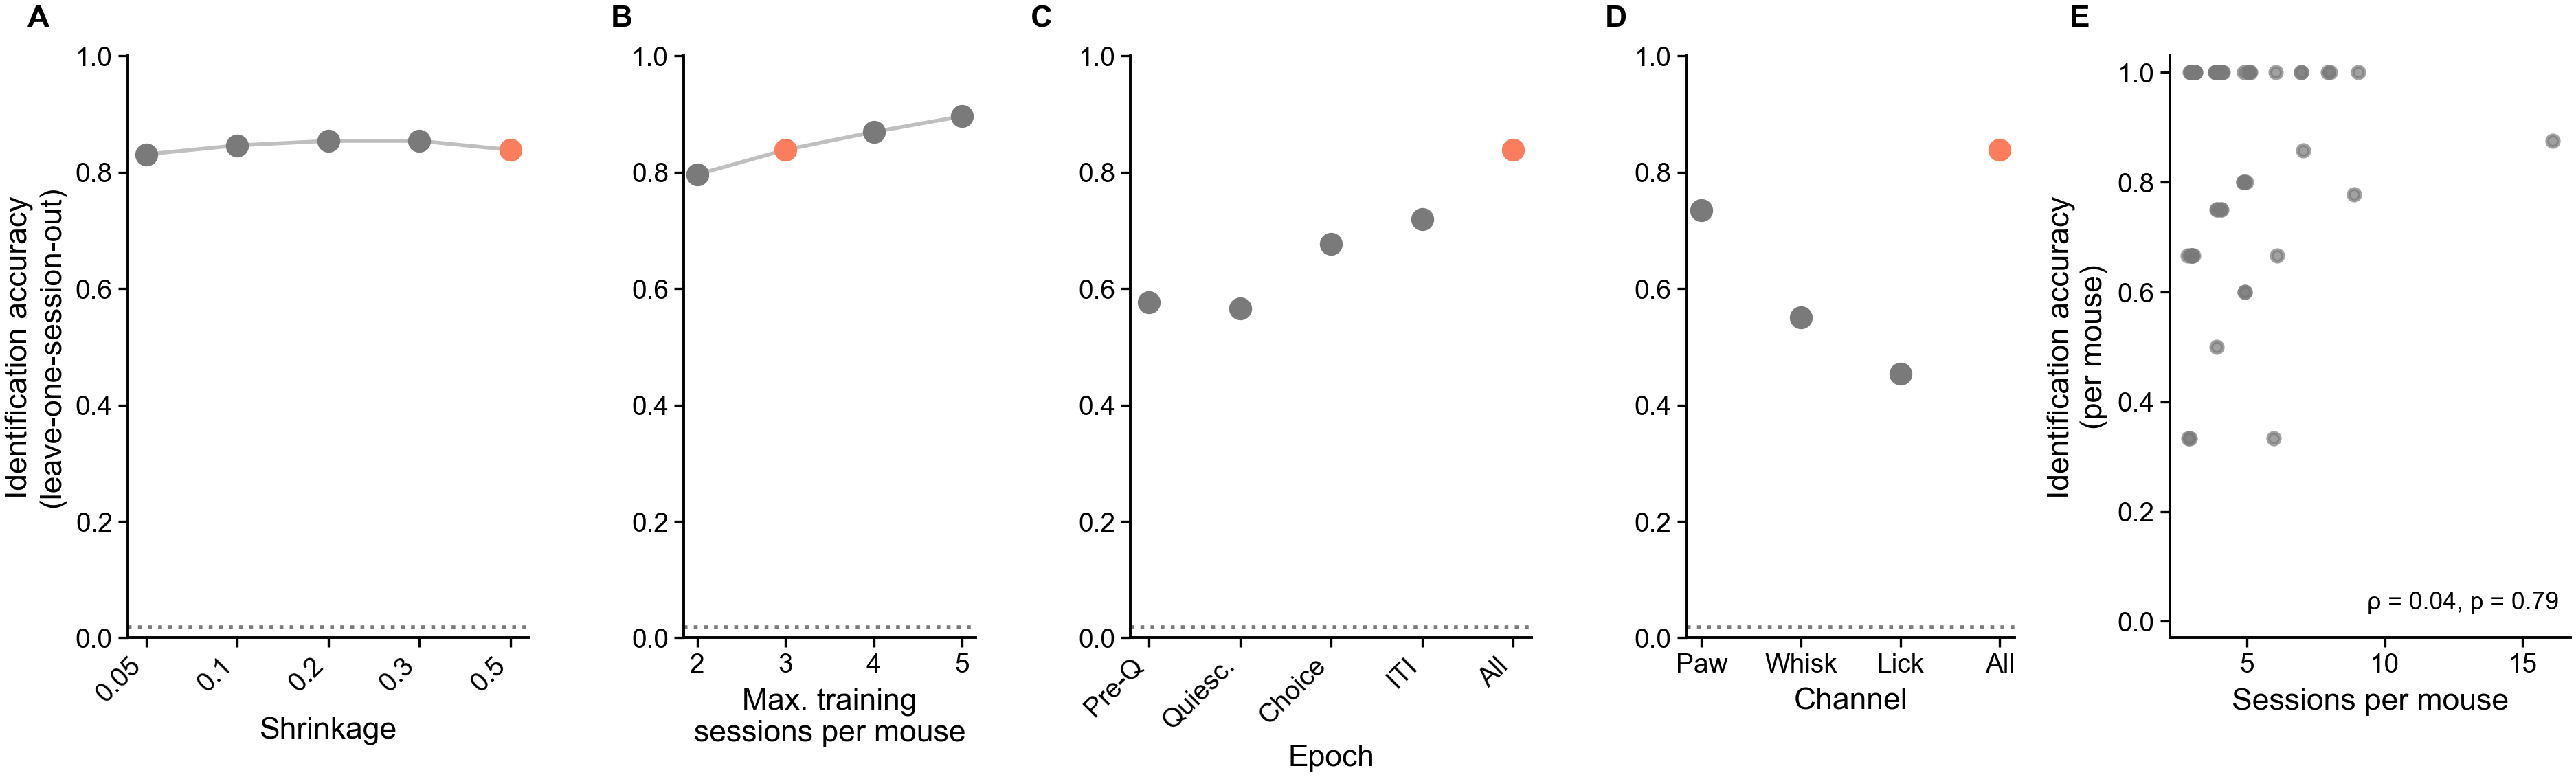

In [21]:
w, h = ps.SIZES[ps.MODE]['double']
fig, axs = plt.subplots(1, 5, figsize=(w * 1.35, h * 0.95),
                        gridspec_kw={'width_ratios': [1.1, 0.8, 1.1, 0.9, 1.1]})


def dot_panel(ax, d, xlabel, highlight=None, join=True):
    keys = list(d)
    for i, k_ in enumerate(keys):
        col = TEST_COLOR['loso'] if k_ == highlight else ps.NEUTRAL
        ax.plot(i, d[k_].mean(), 'o', ms=5, color=col)
    if join:       # only for an ordered axis; categories get no joining line
        ax.plot(range(len(keys)), [d[k_].mean() for k_ in keys], color='0.75', lw=1,
                zorder=0)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([str(k_) for k_ in keys], rotation=45 if len(str(keys[0])) > 3 else 0,
                       ha='right' if len(str(keys[0])) > 3 else 'center')
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1)
    ax.axhline(1 / N_MICE, color=ps.NEUTRAL, ls=':', lw=1)


dot_panel(axs[0], SWEEP['shrinkage'], 'Shrinkage', highlight=FIXED_SHRINKAGE)
axs[0].set_ylabel(f'Identification accuracy\n(leave-one-session-out)')
dot_panel(axs[1], SWEEP['cap'], 'Max. training\nsessions per mouse', highlight=N_PER_MOUSE)
dot_panel(axs[2], {ps.EPOCH_SHORT[i] if i < len(EPOCHS) else k_: v
                   for i, (k_, v) in enumerate(SWEEP['epoch'].items())}, 'Epoch',
          highlight='All', join=False)
dot_panel(axs[3], SWEEP['channel'], 'Channel', highlight='All', join=False)

ax = axs[4]
ax.plot(n_sess.to_numpy() + np.random.default_rng(3).uniform(-0.15, 0.15, len(n_sess)),
        per_mouse.to_numpy(), 'o', ms=3, color=ps.NEUTRAL, alpha=0.7)
ax.set_xlabel('Sessions per mouse')
ax.set_ylabel('Identification accuracy\n(per mouse)')
ax.set_ylim(-0.03, 1.03)
from scipy.stats import spearmanr
_rho, _p = spearmanr(n_sess, per_mouse)
ax.text(0.97, 0.05, f'ρ = {_rho:.2f}, p = {_p:.2g}', transform=ax.transAxes, ha='right',
        fontsize=fs_small)

for ax, letter in zip(axs, 'ABCDE'):
    ax.text(-0.25, 1.04, letter, transform=ax.transAxes, fontweight='bold', va='bottom')
fig.tight_layout()
ps.savefig(fig, 'lda_supplementary_shrinkage', svg=True)
plt.show()

## Numbers for the text

In [22]:
summary = pd.DataFrame({
    'LDA space': [RESULTS[k_]['lda'].mean() for k_ in ('loso', 'mice', 'labs')],
    'SD': [RESULTS[k_]['lda'].std() for k_ in ('loso', 'mice', 'labs')],
    'syllable space': [RESULTS[k_]['syllable'].mean() for k_ in ('loso', 'mice', 'labs')],
    'chance': [RESULTS[k_]['chance'] for k_ in ('loso', 'mice', 'labs')],
    'k for 90% of max': [k_at(CURVES[k_]) for k_ in ('loso', 'mice', 'labs')],
    'errors to labmate': [ERR[k_][0] for k_ in ('loso', 'mice', 'labs')],
    'labmate expected': [ERR[k_][1] for k_ in ('loso', 'mice', 'labs')],
}, index=['leave-one-session-out', 'leave-half-of-mice-out', 'leave-half-of-labs-out'])
print(f'{N_MICE} mice, {n} sessions, {len(n_by_lab)} labs')
print('SD is over repeats (session) or splits (half-splits)')
print(f'discriminants above the shuffled R^2 band: {N_SIG}')
print(f'decorrelated syllable space (no labels, 360 dims), leave-one-session-out: '
      f'{loso["correct_decorr"].mean():.3f}')
print(f'56-way one-out (supplement): LOMO {ONE_OUT["lomo"]["lda"].mean():.3f}, '
      f'LOLO {ONE_OUT["lolo"]["lda"].mean():.3f}; decoy {decoy.mean():.3f} vs '
      f'{DECOY_CHANCE:.3f}')
summary.round(3)

56 mice, 260 sessions, 10 labs
SD is over repeats (session) or splits (half-splits)
discriminants above the shuffled R^2 band: 7
decorrelated syllable space (no labels, 360 dims), leave-one-session-out: 0.862
56-way one-out (supplement): LOMO 0.873, LOLO 0.860; decoy 0.051 vs 0.018


,LDA space,SD,syllable space,chance,k for 90% of max,errors to labmate,labmate expected
leave-one-session-out,0.865,0.000,0.696,0.018,15,0.314,0.088
leave-half-of-mice-out,0.815,0.041,0.773,0.036,12,0.233,0.089
leave-half-of-labs-out,0.810,0.042,0.751,0.036,13,0.418,0.186


## Export for `figure_generation/fig_lda.ipynb`

Everything that figure draws from this notebook, so the figure never reruns the loops above. Rerun this cell whenever the results change.

In [ ]:
import pickle

EXPORT = _root / 'figure_generation' / 'cache' / 'lda_shrinkage_results.pkl'
EXPORT.parent.mkdir(parents=True, exist_ok=True)
export = {
    'meta': {'syllable_file': pathlib.Path(SYLLABLE_FILE).name,
             'written': datetime.now().strftime('%d-%m-%Y %H:%M'),
             'n_sessions': n, 'n_mice': N_MICE, 'n_labs': len(n_by_lab),
             'n_repeats': N_REPEATS, 'n_repeats_one_out': N_REPEATS_ONE_OUT,
             'n_splits': N_SPLITS, 'n_stability': N_STABILITY},
    # identification: 56-way one-out tests (loso / lomo / lolo -> {'lda', 'syllable'}, one value per
    # repeat), and the half-split tests (mice / labs -> {'lda', 'syllable'} per split, + 'chance')
    'one_out': ONE_OUT,
    'half': HALF,
    'decoy': float(decoy.mean()), 'decoy_chance': DECOY_CHANCE,
    # Figure 2A: held-out R^2 per discriminant, bootstrap bands, and the shuffled-label band
    'r2': {'r2': r2, 'true_lo': true_lo, 'true_hi': true_hi,
           'shuf_lo': shuf_lo, 'shuf_hi': shuf_hi, 'n_sig': N_SIG},
    # Figure 2B: accuracy in the first k dimensions (loso, mice, labs, pca)
    'curves': {**CURVES, 'pca': CURVE_PCA},
    # Figure 2C: held-out session -> centroid distances, own mouse / labmates / other labs
    'dist_groups': dist_groups,
    # supplementary axis stability: scheme -> metric -> (refits x dimensions)
    'stability': {'stab': STAB, 'k': K_STAB, 'n_refits': SCHEMES},
}
with open(EXPORT, 'wb') as f:
    pickle.dump(export, f)
print('wrote', EXPORT.relative_to(_root))